In [103]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

In [104]:
df = pd.read_csv('datos_1980-2025_procesados_fatigue.csv')

FEATURES_RENDIMIENTO = ['Age', 'MP', 'PER', 'TS%', 'FTr', 'TRB%', 'AST%', 'STL%', 'USG%', 'W/L%']
FEATURES_FATIGA      = ['fatigue_decay', 'fatigue_streak', 'is_defending_mvp']
FEATURES             = FEATURES_RENDIMIENTO + FEATURES_FATIGA
TARGET               = 'Share'

X_all = df[FEATURES]
y_all = df[TARGET]
seasons = sorted(df['Season'].unique())

shap_values_oof = []
base_values_oof = []
X_test_oof_list = []

## Escenario 1

In [105]:
X_all = df[FEATURES_RENDIMIENTO]
y_all = df[TARGET]
seasons = sorted(df['Season'].unique())

shap_values_oof = []
base_values_oof = []
X_test_oof_list = []

In [106]:
for test_season in seasons:
    train_mask = df['Season'] != test_season
    test_mask  = df['Season'] == test_season

    X_train, y_train = X_all[train_mask], y_all[train_mask]
    X_test, y_test   = X_all[test_mask], y_all[test_mask]

    if len(X_test) == 0:
        continue

    model = XGBRegressor(
        learning_rate=0.05,
        max_depth=3,
        n_estimators=200,
        subsample=0.7,
        random_state=42
    )
    model.fit(X_train, y_train)

    background_data = shap.sample(X_train, 100, random_state=42)

    explainer = shap.TreeExplainer(model, data=background_data, feature_perturbation='interventional')

    shap_explanation_test = explainer(X_test)

    shap_values_oof.append(shap_explanation_test.values)
    base_values_oof.append(shap_explanation_test.base_values)
    X_test_oof_list.append(X_test)

In [107]:
all_shap_values = np.concatenate(shap_values_oof, axis=0)
all_base_values = np.concatenate(base_values_oof, axis=0)
all_X_test      = pd.concat(X_test_oof_list, axis=0)

df_meta_oof = df.loc[all_X_test.index].reset_index(drop=True)

In [108]:
shap_explanation_esc1 = shap.Explanation(
    values=all_shap_values,
    base_values=all_base_values,
    data=all_X_test.values,
    feature_names=FEATURES_RENDIMIENTO
)

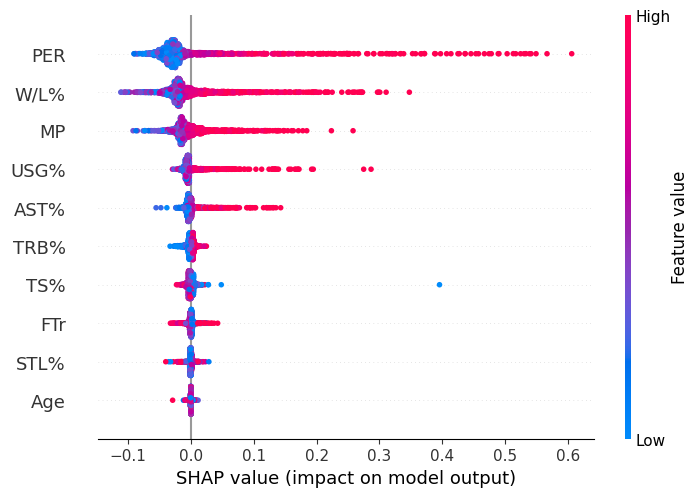

In [109]:
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_explanation_esc1, max_display=10)

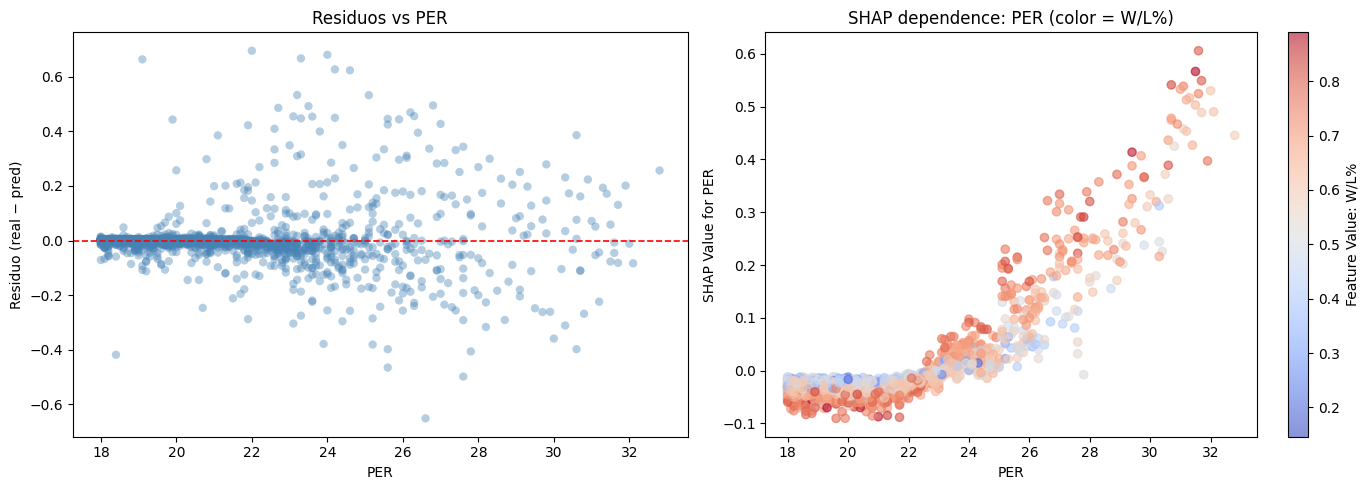

In [110]:
y_pred_oof = shap_explanation_esc1.base_values + shap_explanation_esc1.values.sum(axis=1)

residuos_oof = df_meta_oof["Share"].values - y_pred_oof

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_meta_oof["PER"], residuos_oof, alpha=0.4, color="steelblue", edgecolors="none")
axes[0].axhline(0, color="red", linewidth=1.2, linestyle="--")
axes[0].set_xlabel("PER")
axes[0].set_ylabel("Residuo (real − pred)")
axes[0].set_title("Residuos vs PER")

per_index = FEATURES.index("PER")
wl_index = FEATURES.index("W/L%")

x_data = shap_explanation_esc1.data[:, per_index]
y_data = shap_explanation_esc1.values[:, per_index]
c_data = shap_explanation_esc1.data[:, wl_index]

scatter_plot = axes[1].scatter(x_data, y_data, c=c_data, cmap='coolwarm', alpha=0.6)
axes[1].set_xlabel(f"{FEATURES[per_index]}")
axes[1].set_ylabel(f"SHAP Value for {FEATURES[per_index]}")
axes[1].set_title("SHAP dependence: PER (color = W/L%)")

cbar = fig.colorbar(scatter_plot, ax=axes[1])
cbar.set_label(f"Feature Value: {FEATURES[wl_index]}")

plt.tight_layout()
plt.show()

In [111]:
df_errores_esc1 = df_meta_oof.copy()

df_errores_esc1["y_pred"] = shap_explanation_esc1.base_values + shap_explanation_esc1.values.sum(axis=1)

df_errores_esc1["error_abs"] = abs(df_errores_esc1["Share"] - df_errores_esc1["y_pred"])

casos_error_esc1 = df_errores_esc1.nlargest(5, "error_abs")[[ "Player", "Season", "Share", "y_pred", "error_abs"]]

print("=== TOP 5 CASOS DE MAYOR ERROR ABSOLUTO (ESCENARIO 1 - VALIDACIÓN LOSO) ===")
display(casos_error_esc1)

=== TOP 5 CASOS DE MAYOR ERROR ABSOLUTO (ESCENARIO 1 - VALIDACIÓN LOSO) ===


,Player,Season,Share,y_pred,error_abs
965,Steve Nash,2005,0.839,0.144227,0.694773
749,Allen Iverson,2001,0.904,0.224029,0.679971
1009,Steve Nash,2006,0.739,0.072413,0.666587
811,Jason Kidd,2002,0.712,0.048886,0.663114
929,Amar'e Stoudemire,2005,0.032,0.682848,0.650848



Steve Nash 2005  |  Real: 0.839  Pred: 0.144
Shape of values for this instance: (10,)


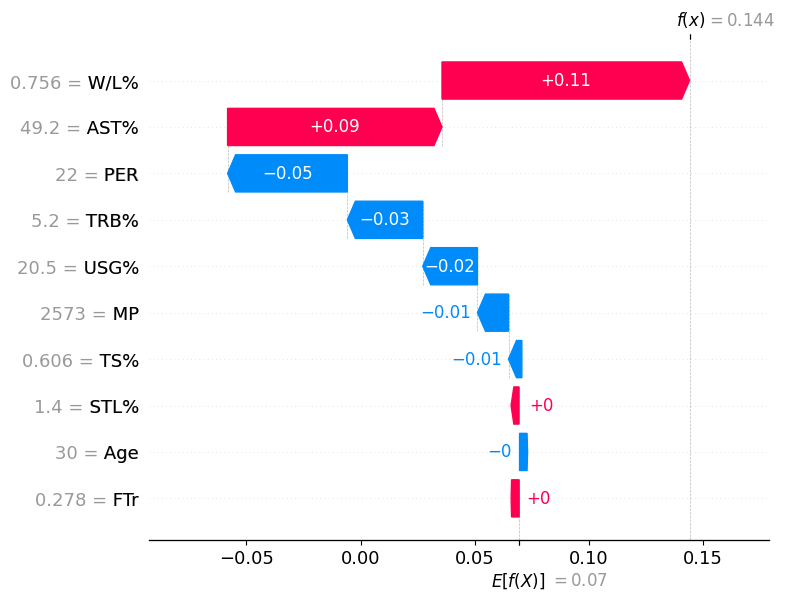


Allen Iverson 2001  |  Real: 0.904  Pred: 0.224
Shape of values for this instance: (10,)


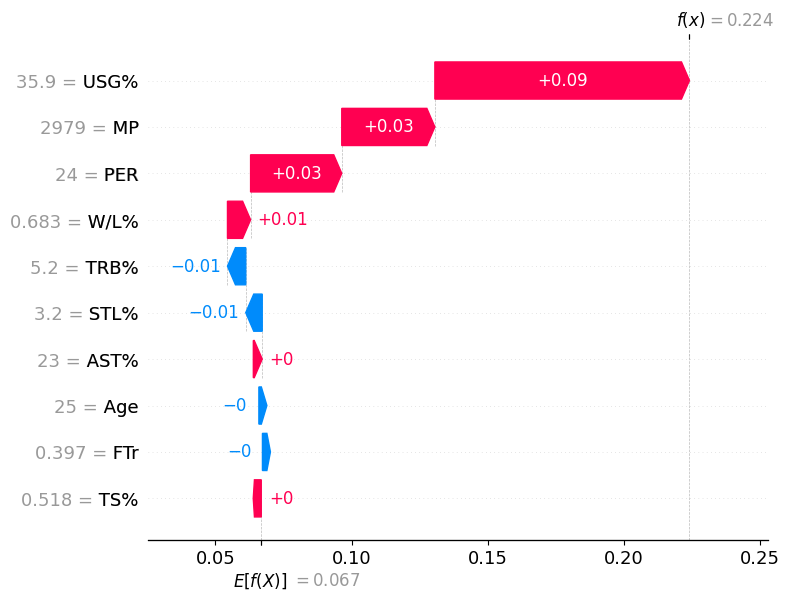


Steve Nash 2006  |  Real: 0.739  Pred: 0.072
Shape of values for this instance: (10,)


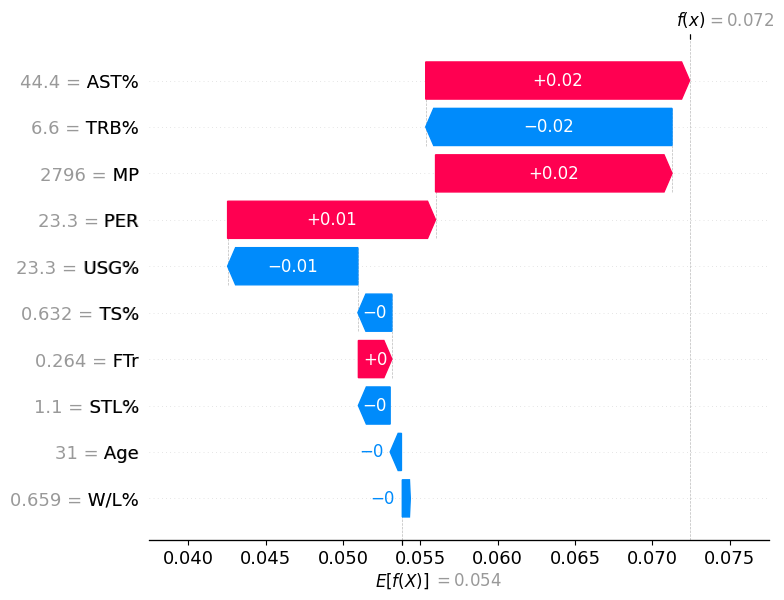


Jason Kidd 2002  |  Real: 0.712  Pred: 0.049
Shape of values for this instance: (10,)


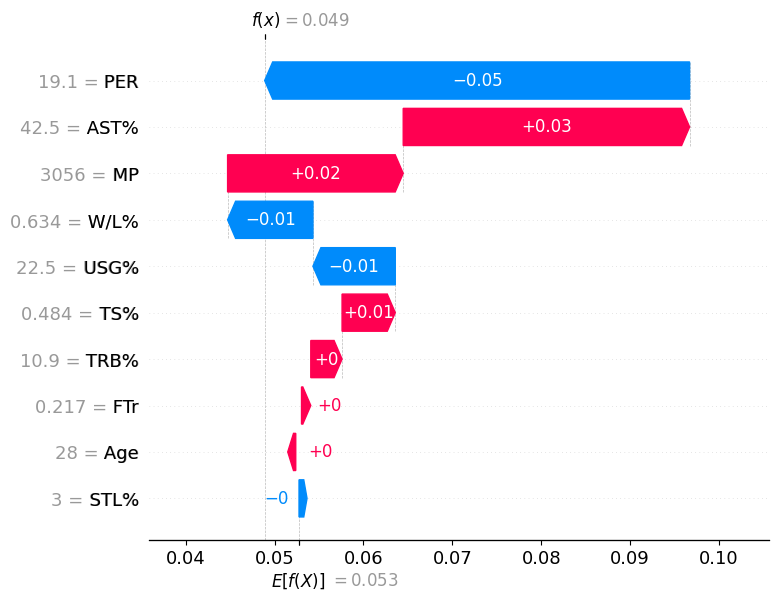


Amar'e Stoudemire 2005  |  Real: 0.032  Pred: 0.683
Shape of values for this instance: (10,)


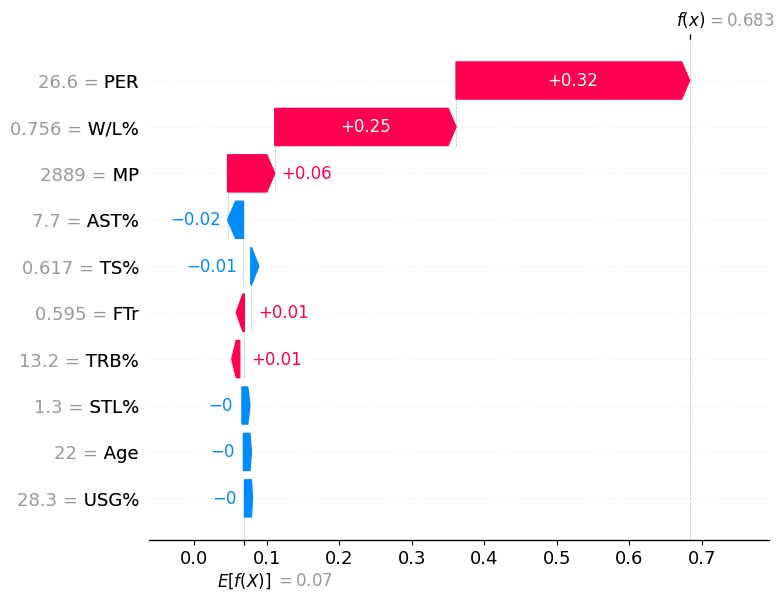

In [112]:
for _, row in casos_error_esc1.iterrows():
    mask = (df["Player"] == row["Player"]) & (df["Season"] == row["Season"])
    pos_in_oof = df_meta_oof[(df_meta_oof["Player"] == row["Player"]) & (df_meta_oof["Season"] == row["Season"])].index[0]

    print(f"\n{row['Player']} {row['Season']}  |  Real: {row['Share']:.3f}  Pred: {row['y_pred']:.3f}")

    instance_explanation = shap_explanation_esc1[pos_in_oof]
    print(f"Shape of values for this instance: {instance_explanation.values.shape}")

    shap.plots.waterfall(instance_explanation, max_display=len(instance_explanation.values))

## Escenario 2

In [113]:
X_all = df[FEATURES]
y_all = df[TARGET]
seasons = sorted(df['Season'].unique())

shap_values_oof = []
base_values_oof = []
X_test_oof_list = []

In [114]:
for test_season in seasons:
    train_mask = df['Season'] != test_season
    test_mask  = df['Season'] == test_season

    X_train, y_train = X_all[train_mask], y_all[train_mask]
    X_test, y_test   = X_all[test_mask], y_all[test_mask]

    model = XGBRegressor(
        learning_rate=0.05,
        max_depth=3,
        n_estimators=100,
        subsample=0.7,
        random_state=42
    )
    model.fit(X_train, y_train)

    background_data = shap.sample(X_train, 100, random_state=42)

    explainer = shap.TreeExplainer(model, data=background_data, feature_perturbation='interventional')

    shap_explanation_test = explainer(X_test)

    shap_values_oof.append(shap_explanation_test.values)
    base_values_oof.append(shap_explanation_test.base_values)
    X_test_oof_list.append(X_test)

In [115]:
all_shap_values = np.concatenate(shap_values_oof, axis=0)
all_base_values = np.concatenate(base_values_oof, axis=0)
all_X_test      = pd.concat(X_test_oof_list, axis=0)

df_meta_oof = df.loc[all_X_test.index].reset_index(drop=True)

In [116]:
shap_explanation_esc2 = shap.Explanation(
    values=all_shap_values,
    base_values=all_base_values,
    data=all_X_test.values,
    feature_names=FEATURES
)

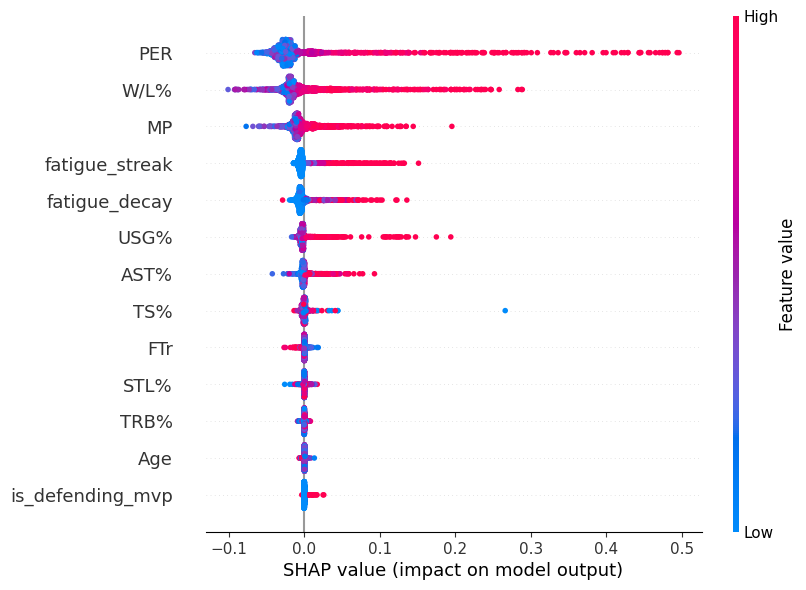

In [117]:
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_explanation_esc2, max_display=13)

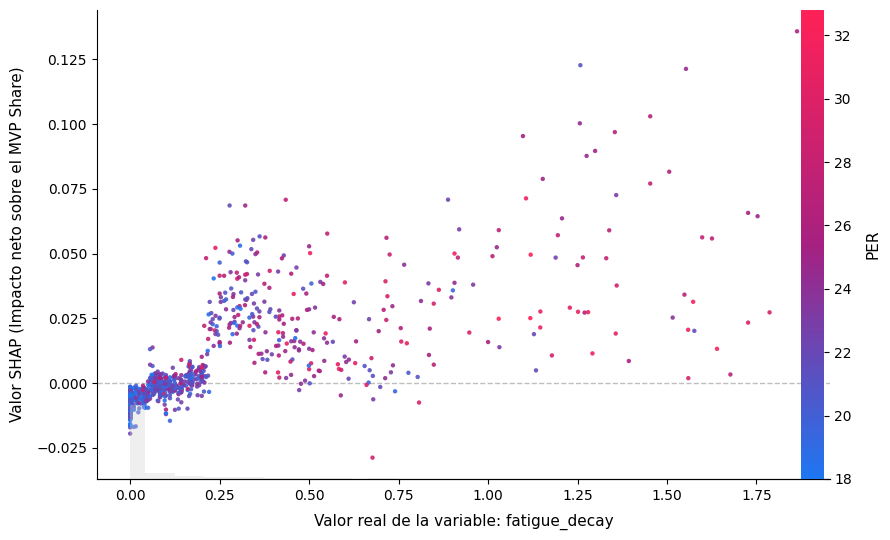

In [118]:

decay_index = FEATURES.index("fatigue_decay")
per_index = FEATURES.index("PER") if "PER" in FEATURES else FEATURES.index("fatigue_streak")

x_data = shap_explanation_esc2.data[:, decay_index]
y_data = shap_explanation_esc2.values[:, decay_index]
c_data = shap_explanation_esc2.data[:, per_index]

colors = ["#1e77f4", "#a62181", "#ff2157"]
shap_cmap = LinearSegmentedColormap.from_list("shap_custom", colors, N=256)

fig, ax = plt.subplots(figsize=(9, 5.5))

ax_hist = ax.twinx()
ax_hist.hist(x_data, bins=45, color="lightgray", alpha=0.35, density=False, zorder=1)
ax_hist.get_yaxis().set_visible(False)
ax_hist.spines['top'].set_visible(False)
ax_hist.spines['right'].set_visible(False)
ax_hist.spines['left'].set_visible(False)
ax_hist.set_ylim(0, ax_hist.get_ylim()[1] * 6)

ax.axhline(0, color="gray", linewidth=1, linestyle="--", alpha=0.5, zorder=1)

scatter_plot = ax.scatter(
    x_data, y_data, c=c_data, cmap=shap_cmap,
    s=10, alpha=0.9, edgecolors="none", zorder=2
)

ax.set_xlabel("Valor real de la variable: fatigue_decay", fontsize=11, labelpad=8)
ax.set_ylabel("Valor SHAP (Impacto neto sobre el MVP Share)", fontsize=11, labelpad=8)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

cbar = fig.colorbar(scatter_plot, ax=ax, pad=0.02, fraction=0.04)
cbar.set_label("PER" if "PER" in FEATURES else "fatigue_streak", fontsize=11, labelpad=10)
cbar.solids.set_edgecolor("face")
cbar.outline.set_visible(False)

plt.tight_layout()
plt.show()

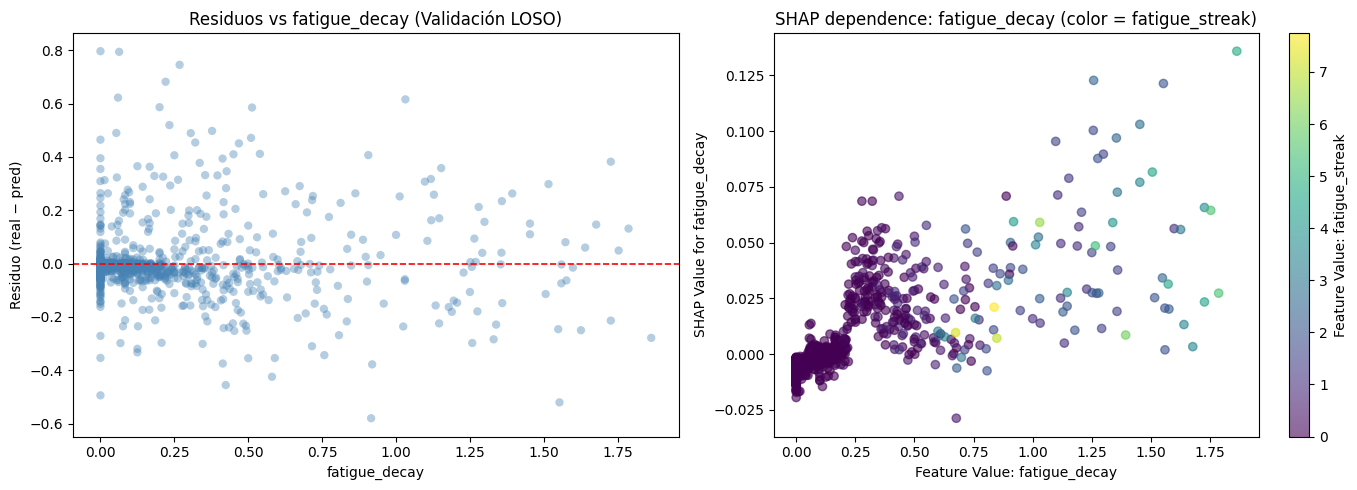

In [119]:
y_pred_oof_esc2 = shap_explanation_esc2.base_values + shap_explanation_esc2.values.sum(axis=1)

residuos_oof_esc2 = df_meta_oof["Share"].values - y_pred_oof_esc2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_meta_oof["fatigue_decay"], residuos_oof_esc2, alpha=0.4, color="steelblue", edgecolors="none")
axes[0].axhline(0, color="red", linewidth=1.2, linestyle="--")
axes[0].set_xlabel("fatigue_decay")
axes[0].set_ylabel("Residuo (real − pred)")
axes[0].set_title("Residuos vs fatigue_decay (Validación LOSO)")

decay_index  = FEATURES.index("fatigue_decay")
streak_index = FEATURES.index("fatigue_streak")

x_data = shap_explanation_esc2.data[:, decay_index]
y_data = shap_explanation_esc2.values[:, decay_index]
c_data = shap_explanation_esc2.data[:, streak_index]

scatter_plot = axes[1].scatter(x_data, y_data, c=c_data, cmap='viridis', alpha=0.6)
axes[1].set_xlabel(f"Feature Value: {FEATURES[decay_index]}")
axes[1].set_ylabel(f"SHAP Value for {FEATURES[decay_index]}")
axes[1].set_title("SHAP dependence: fatigue_decay (color = fatigue_streak)")

cbar = fig.colorbar(scatter_plot, ax=axes[1])
cbar.set_label(f"Feature Value: {FEATURES[streak_index]}")

plt.tight_layout()
plt.show()

In [120]:
shap_df_esc2 = pd.DataFrame(shap_explanation_esc2.values, columns=FEATURES)

shap_df_esc2[["Player", "Season", "Share"]] = df_meta_oof[["Player", "Season", "Share"]]

print("📈 Mayor impacto POSITIVO de fatigue_decay (Fuera de la muestra):")
display(shap_df_esc2.nlargest(10, "fatigue_decay")[[ "Player", "Season", "Share", "fatigue_decay"]])

print("\n📉 Mayor impacto NEGATIVO de fatigue_decay (Fuera de la muestra):")
display(shap_df_esc2.nsmallest(10, "fatigue_decay")[[ "Player", "Season", "Share", "fatigue_decay"]])

📈 Mayor impacto POSITIVO de fatigue_decay (Fuera de la muestra):


,Player,Season,Share,fatigue_decay
265,Larry Bird,1987,0.347,0.135815
1108,Steve Nash,2008,0.014,0.122731
1565,Stephen Curry,2017,0.051,0.121324
198,Larry Bird,1985,0.978,0.103003
1144,Kobe Bryant,2009,0.577,0.100297
877,Tim Duncan,2003,0.808,0.096898
685,Karl Malone,1999,0.701,0.095360
647,Michael Jordan,1998,0.934,0.089646
1088,Dirk Nowitzki,2008,0.004,0.087707
367,Magic Johnson,1990,0.691,0.081609



📉 Mayor impacto NEGATIVO de fatigue_decay (Fuera de la muestra):


,Player,Season,Share,fatigue_decay
385,Charles Barkley,1991,0.231,-0.028786
1151,Pau Gasol,2009,0.000,-0.019495
731,Kobe Bryant,2000,0.002,-0.017119
1105,Paul Pierce,2008,0.001,-0.016940
616,Tim Hardaway,1997,0.207,-0.016696
1153,Rajon Rondo,2009,0.000,-0.016393
1038,Jason Terry,2007,0.000,-0.016145
690,Malik Rose,1999,0.000,-0.015986
1160,Zydrunas Ilgauskas,2009,0.000,-0.015774
556,Gary Payton,1996,0.087,-0.014541


In [121]:
df_errores_esc2 = df_meta_oof.copy()

df_errores_esc2["y_pred"] = shap_explanation_esc2.base_values + shap_explanation_esc2.values.sum(axis=1)

df_errores_esc2["error_abs"] = abs(df_errores_esc2["Share"] - df_errores_esc2["y_pred"])

casos_error_esc2 = df_errores_esc2.nlargest(5, "error_abs")[[ "Player", "Season", "Share", "y_pred", "error_abs"]]

print("=== TOP 5 CASOS DE MAYOR ERROR ABSOLUTO (ESCENARIO 2 - VALIDACIÓN LOSO) ===")
display(casos_error_esc2)

=== TOP 5 CASOS DE MAYOR ERROR ABSOLUTO (ESCENARIO 2 - VALIDACIÓN LOSO) ===


,Player,Season,Share,y_pred,error_abs
1218,Derrick Rose,2011,0.977,0.180386,0.796614
965,Steve Nash,2005,0.839,0.044789,0.794211
749,Allen Iverson,2001,0.904,0.158544,0.745456
811,Jason Kidd,2002,0.712,0.029998,0.682002
663,Alonzo Mourning,1999,0.655,0.032488,0.622512



Derrick Rose 2011  |  Real: 0.977  Pred: 0.180


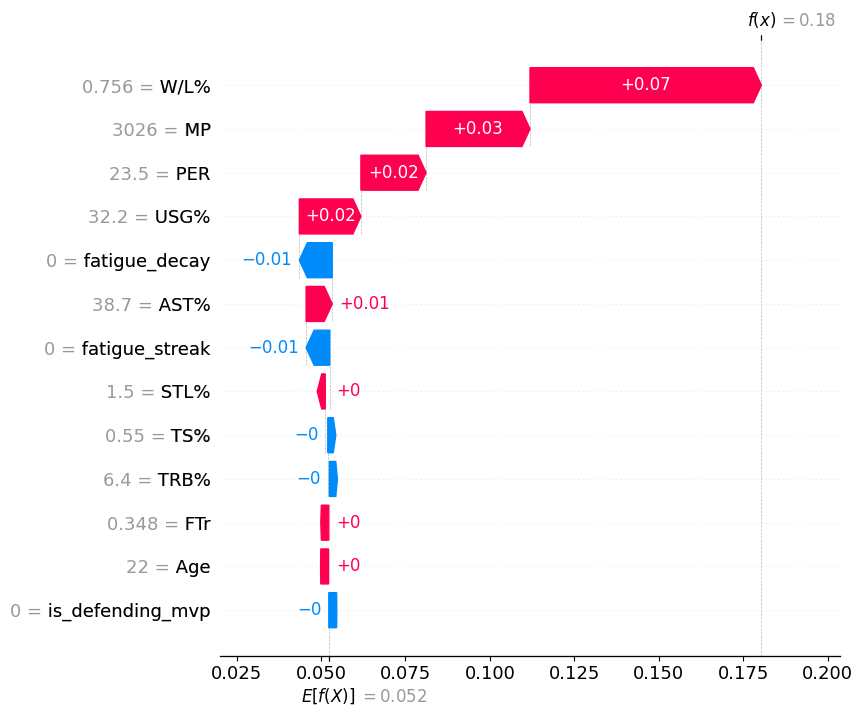


Steve Nash 2005  |  Real: 0.839  Pred: 0.045


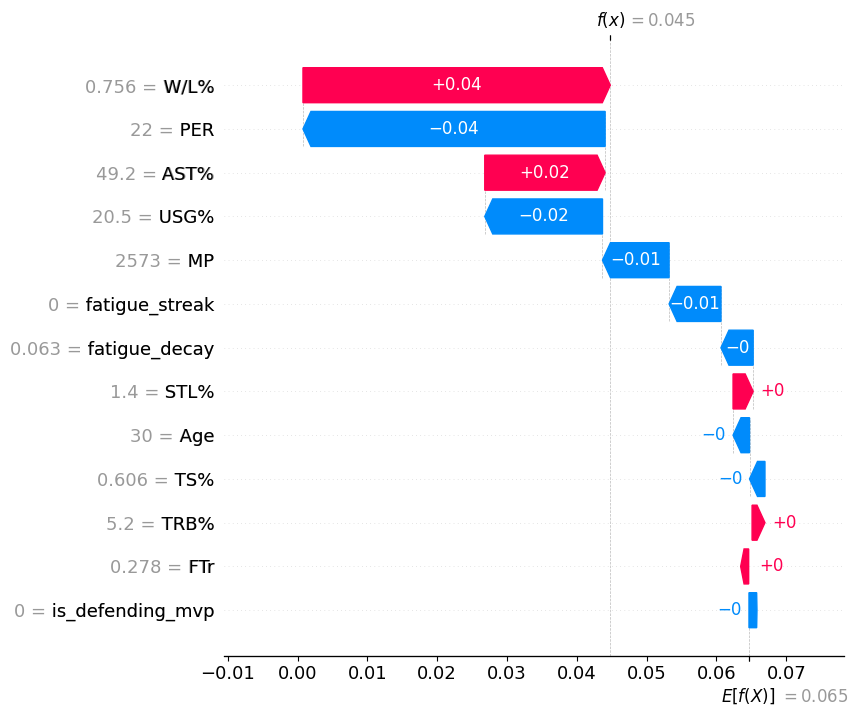


Allen Iverson 2001  |  Real: 0.904  Pred: 0.159


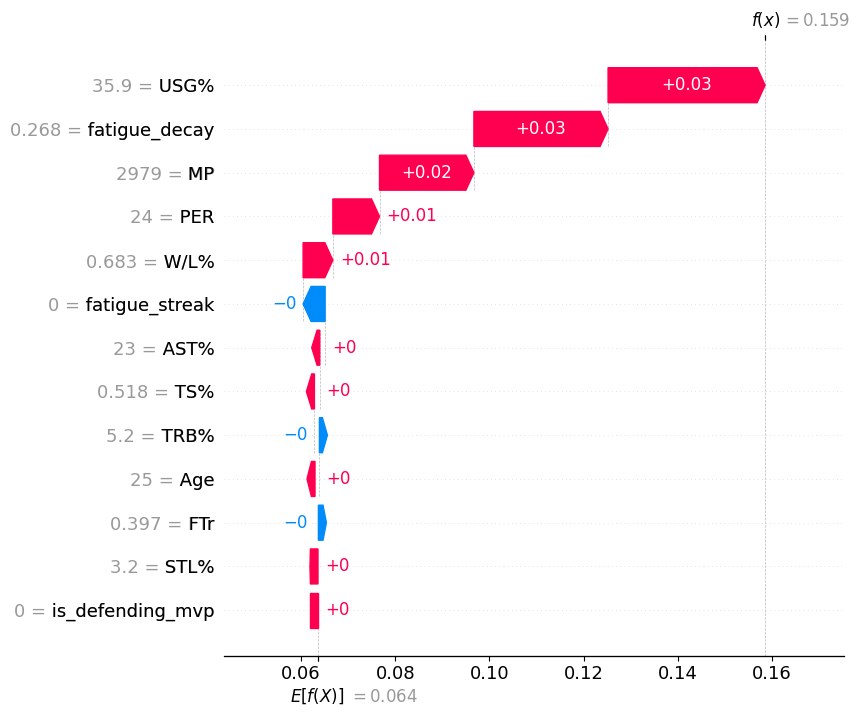


Jason Kidd 2002  |  Real: 0.712  Pred: 0.030


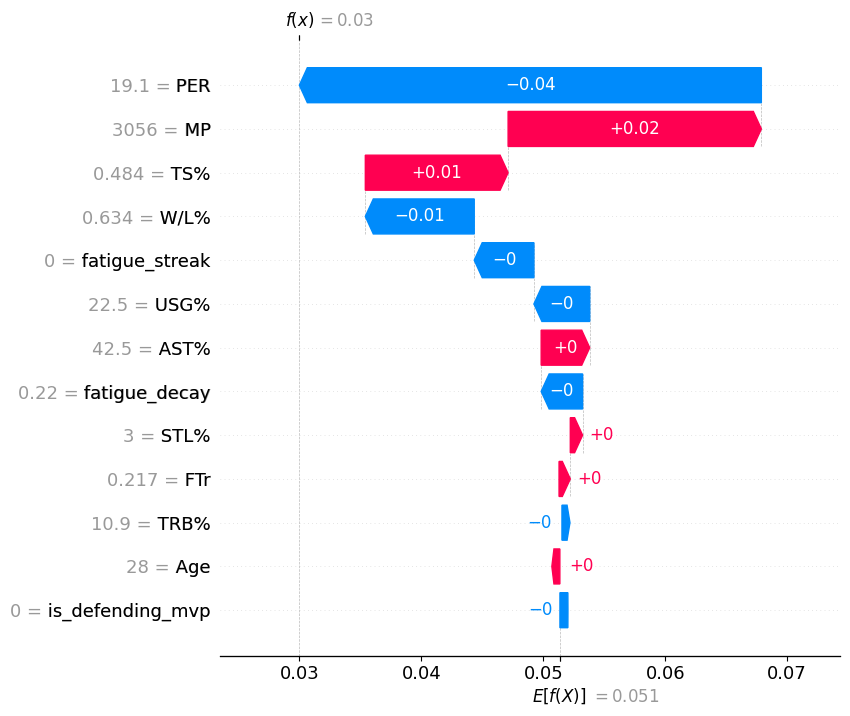


Alonzo Mourning 1999  |  Real: 0.655  Pred: 0.032


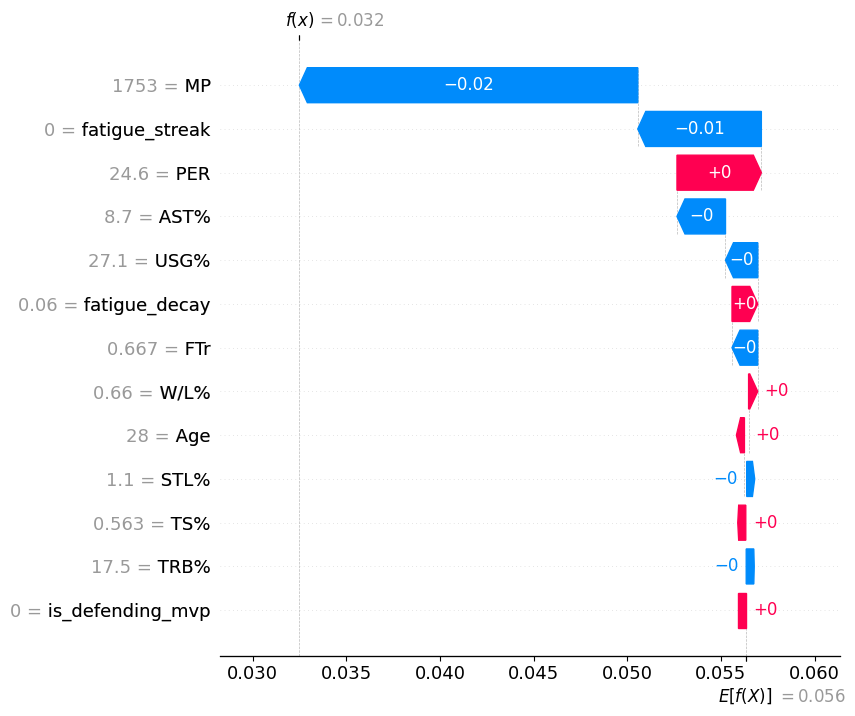

In [122]:
for _, row in casos_error_esc2.iterrows():
    mask = (df_meta_oof["Player"] == row["Player"]) & (df_meta_oof["Season"] == row["Season"])
    pos  = df_meta_oof[mask].index[0]

    print(f"\n{row['Player']} {row['Season']}  |  Real: {row['Share']:.3f}  Pred: {row['y_pred']:.3f}")

    plt.figure(figsize=(9, 6))

    shap.plots.waterfall(shap_explanation_esc2[pos], max_display=13)

In [123]:
analysis_streak = df_meta_oof[['Player', 'Season', 'Share', 'fatigue_streak']].copy()
analysis_streak = analysis_streak.rename(columns={'fatigue_streak': 'streak_real'})

streak_idx = FEATURES.index('fatigue_streak')
analysis_streak['streak_shap'] = shap_explanation_esc2.values[:, streak_idx]

analysis_streak['streak_bin'] = pd.cut(analysis_streak['streak_real'], bins=5)

impacto_streak = analysis_streak.groupby('streak_bin', observed=True).agg(
    N_casos=('streak_real', 'count'),
    Streak_mean=('streak_real', 'mean'),
    Share_mean=('Share', 'mean'),
    SHAP_mean=('streak_shap', 'mean')
)

print('\nImpacto SHAP promedio de fatigue_streak por intervalos (Validación LOSO):')
display(impacto_streak.round(5))


Impacto SHAP promedio de fatigue_streak por intervalos (Validación LOSO):


,N_casos,Streak_mean,Share_mean,SHAP_mean
streak_bin,,,,
"(-0.00775, 1.55]",1949,0.04592,0.04582,-0.00205
"(1.55, 3.1]",34,2.25000,0.45265,0.07413
"(3.1, 4.65]",14,3.78571,0.59457,0.08545
"(4.65, 6.2]",5,5.40000,0.53240,0.06772
"(6.2, 7.75]",4,7.12500,0.38600,0.05769


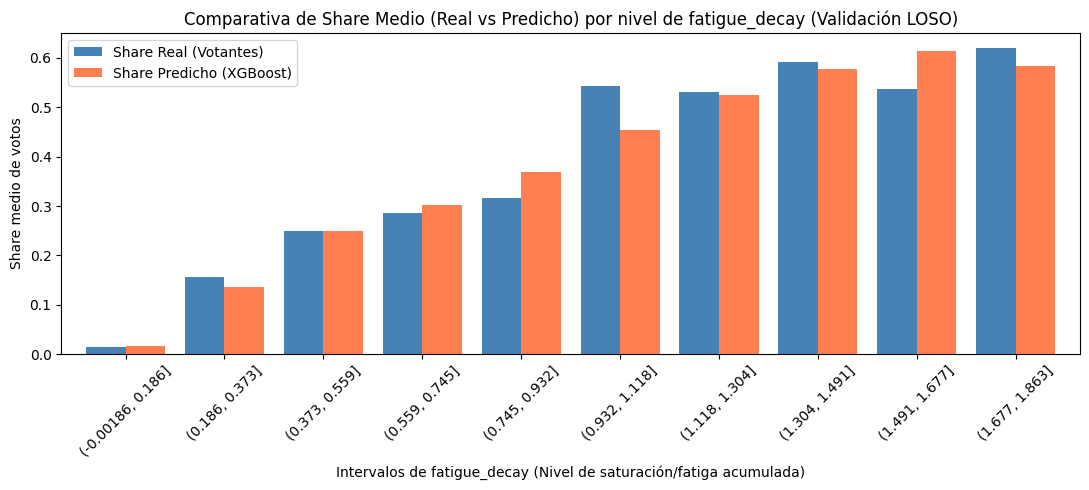

In [124]:

df_analysis_decay = df_meta_oof.copy()

df_analysis_decay["y_pred"] = shap_explanation_esc2.base_values + shap_explanation_esc2.values.sum(axis=1)

df_analysis_decay['fatigue_bin'] = pd.cut(df_analysis_decay['fatigue_decay'], bins=10)

grouped_decay = df_analysis_decay.groupby('fatigue_bin', observed=True)[['Share', 'y_pred']].mean()

grouped_decay.plot(kind='bar', figsize=(11, 5), color=['steelblue', 'coral'], width=0.8)

plt.title("Comparativa de Share Medio (Real vs Predicho) por nivel de fatigue_decay (Validación LOSO)")
plt.xlabel("Intervalos de fatigue_decay (Nivel de saturación/fatiga acumulada)")
plt.ylabel("Share medio de votos")
plt.legend(["Share Real (Votantes)", "Share Predicho (XGBoost)"])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

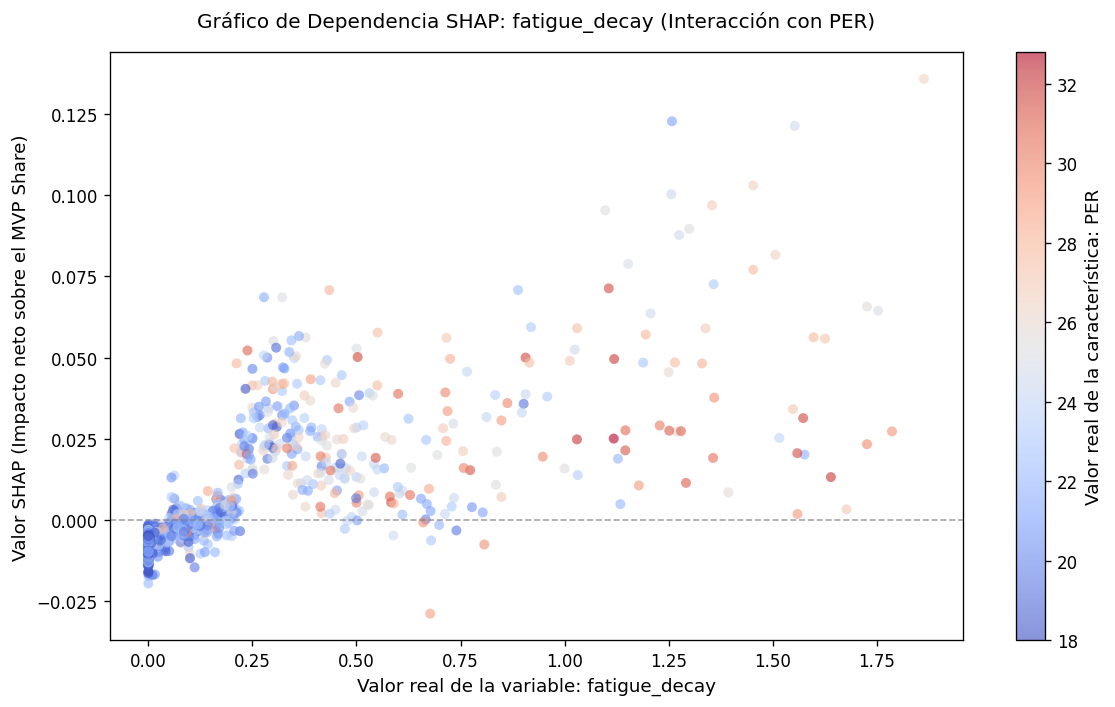

In [125]:


fig, ax = plt.subplots(figsize=(10, 6), dpi=120)

decay_idx = FEATURES.index("fatigue_decay")
per_idx   = FEATURES.index("PER")

x_data = shap_explanation_esc2.data[:, decay_idx]
y_data = shap_explanation_esc2.values[:, decay_idx]
c_data = shap_explanation_esc2.data[:, per_idx]

scatter_plot = ax.scatter(x_data, y_data, c=c_data, cmap='coolwarm', alpha=0.6, edgecolors='none')

cbar = fig.colorbar(scatter_plot, ax=ax)
cbar.set_label("Valor real de la característica: PER", fontsize=11)

ax.set_xlabel("Valor real de la variable: fatigue_decay", fontsize=11)
ax.set_ylabel("Valor SHAP (Impacto neto sobre el MVP Share)", fontsize=11)
ax.set_title("Gráfico de Dependencia SHAP: fatigue_decay (Interacción con PER)", fontsize=12, pad=15)

ax.axhline(0, color="gray", linestyle="--", linewidth=1, alpha=0.7)

plt.tight_layout()
plt.show()

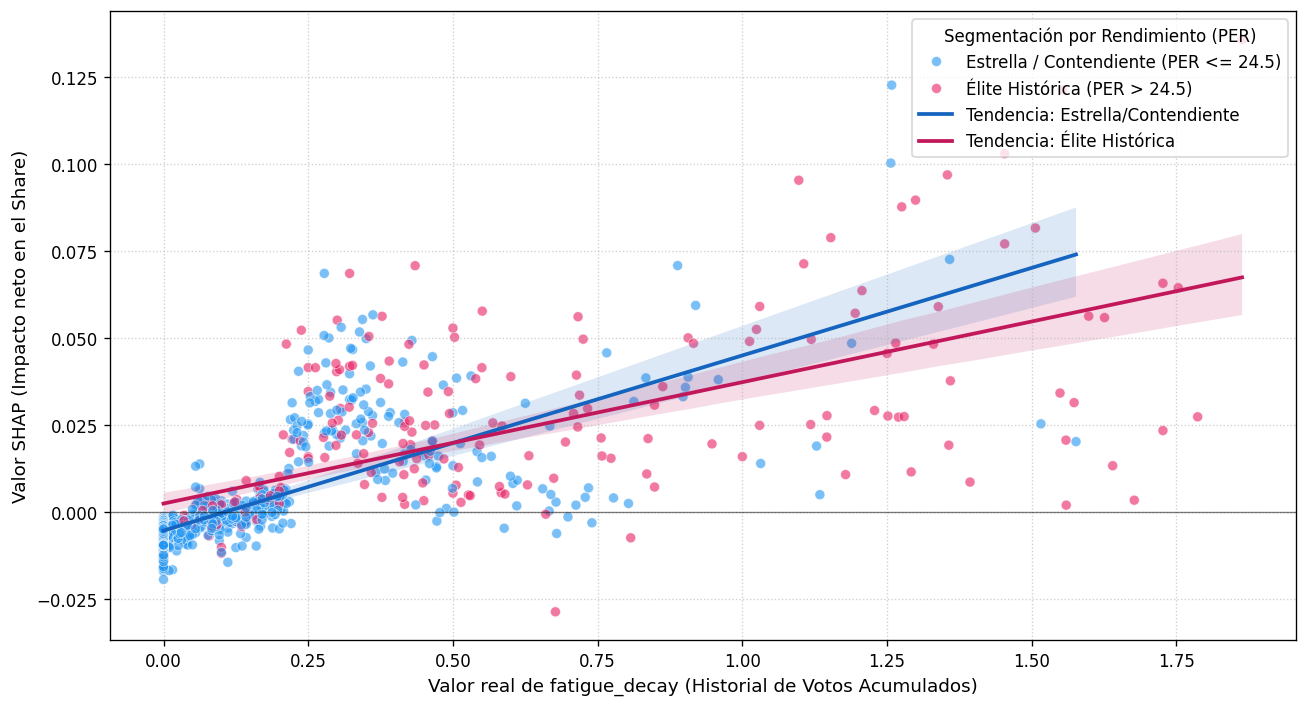

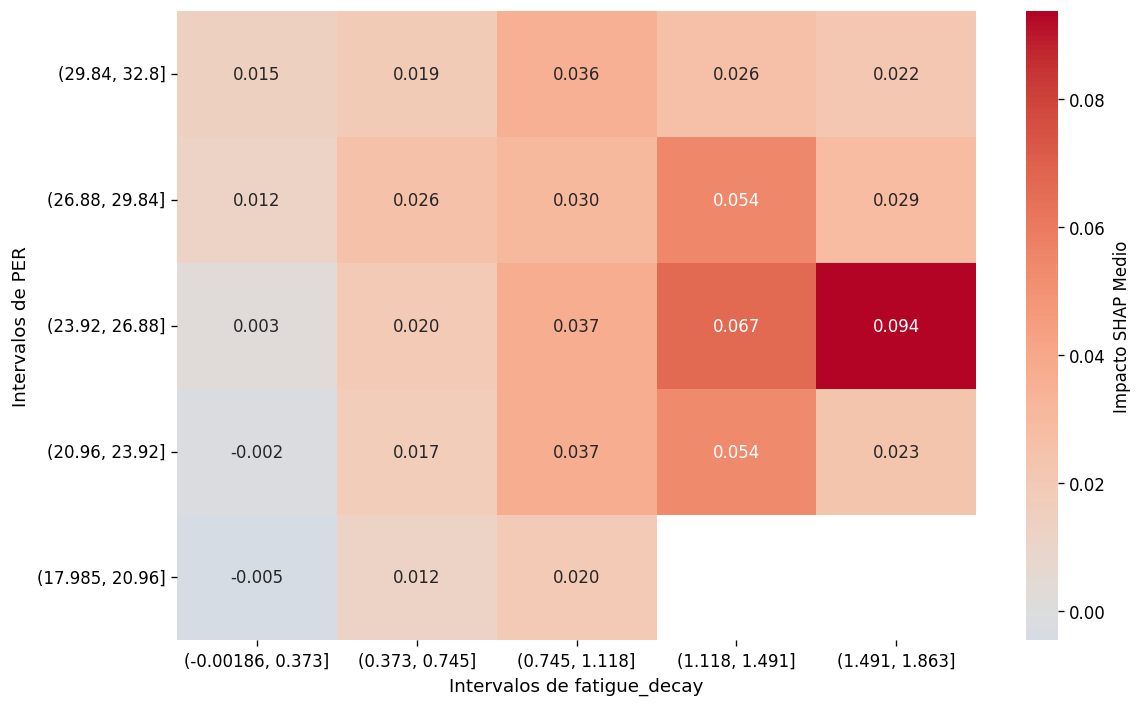


--- TABLA: IMPACTO SHAP PROMEDIO DE FATIGUE_STREAK POR INTERVALOS (VALIDACIÓN LOSO) ---


,N_casos,Streak_mean,Share_mean,SHAP_mean
streak_bin,,,,
"(-0.00775, 1.55]",1949,0.04592,0.04582,-0.00205
"(1.55, 3.1]",34,2.25000,0.45265,0.07413
"(3.1, 4.65]",14,3.78571,0.59457,0.08545
"(4.65, 6.2]",5,5.40000,0.53240,0.06772
"(6.2, 7.75]",4,7.12500,0.38600,0.05769


In [126]:


df_interaccion = df_meta_oof[['Player', 'Season', 'Share', 'PER', 'fatigue_decay', 'fatigue_streak']].copy()

decay_index  = FEATURES.index('fatigue_decay')
streak_index = FEATURES.index('fatigue_streak')

df_interaccion['shap_fatigue_decay']  = shap_explanation_esc2.values[:, decay_index]
df_interaccion['shap_fatigue_streak'] = shap_explanation_esc2.values[:, streak_index]

umbral_per = 24.5
df_interaccion['Grupo_PER'] = np.where(
    df_interaccion['PER'] > umbral_per,
    'Élite Histórica (PER > 24.5)',
    'Estrella / Contendiente (PER <= 24.5)'
)

fig, ax = plt.subplots(figsize=(11, 6), dpi=120)

sns.scatterplot(
    data=df_interaccion, x='fatigue_decay', y='shap_fatigue_decay',
    hue='Grupo_PER', palette={'Élite Histórica (PER > 24.5)': '#e91e63', 'Estrella / Contendiente (PER <= 24.5)': '#2196f3'},
    alpha=0.6, ax=ax
)

sns.regplot(
    data=df_interaccion[df_interaccion['PER'] <= umbral_per], x='fatigue_decay', y='shap_fatigue_decay',
    scatter=False, color='#1565c0', label='Tendencia: Estrella/Contendiente', ax=ax
)
sns.regplot(
    data=df_interaccion[df_interaccion['PER'] > umbral_per], x='fatigue_decay', y='shap_fatigue_decay',
    scatter=False, color='#c2185b', label='Tendencia: Élite Histórica', ax=ax
)

ax.set_xlabel("Valor real de fatigue_decay (Historial de Votos Acumulados)", fontsize=11)
ax.set_ylabel("Valor SHAP (Impacto neto en el Share)", fontsize=11)
ax.axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
ax.legend(title="Segmentación por Rendimiento (PER)", title_fontsize='10', loc='upper right')
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

df_interaccion['bin_fatigue'] = pd.cut(df_interaccion['fatigue_decay'], bins=5)
df_interaccion['bin_PER']     = pd.cut(df_interaccion['PER'], bins=5)

matriz_pivot = df_interaccion.pivot_table(
    values='shap_fatigue_decay', index='bin_PER', columns='bin_fatigue',
    aggfunc='mean', observed=True
).sort_index(ascending=False)

plt.figure(figsize=(10, 6), dpi=120)
sns.heatmap(
    matriz_pivot, cmap='coolwarm', center=0, annot=True, fmt=".3f",
    cbar_kws={'label': 'Impacto SHAP Medio'}
)
plt.xlabel("Intervalos de fatigue_decay", fontsize=11)
plt.ylabel("Intervalos de PER", fontsize=11)
plt.tight_layout()
plt.show()

df_interaccion['streak_bin'] = pd.cut(df_interaccion['fatigue_streak'], bins=5)

impacto_streak = df_interaccion.groupby('streak_bin', observed=True).agg(
    N_casos=('fatigue_streak', 'count'),
    Streak_mean=('fatigue_streak', 'mean'),
    Share_mean=('Share', 'mean'),
    SHAP_mean=('shap_fatigue_streak', 'mean')
)

print("\n--- TABLA: IMPACTO SHAP PROMEDIO DE FATIGUE_STREAK POR INTERVALOS (VALIDACIÓN LOSO) ---")
display(impacto_streak.round(5))


--- RANKING HISTÓRICO: MAYORES RESIDUOS NEGATIVOS (CASTIGOS DEL JURADO - VALIDACIÓN LOSO) ---


,Player,Season,Share,y_pred,Residuo_Neto,fatigue_decay
1546,Kevin Durant,2017,0.002,0.5818,-0.5798,0.9156
1565,Stephen Curry,2017,0.051,0.5714,-0.5204,1.5530
929,Amar'e Stoudemire,2005,0.032,0.5260,-0.4940,0.0000
1221,Dwyane Wade,2011,0.020,0.4753,-0.4553,0.4240
698,Shaquille O'Neal,1999,0.075,0.4993,-0.4243,0.5804
1010,Tim Duncan,2006,0.026,0.4038,-0.3778,0.9193
1618,Anthony Davis,2019,0.000,0.3745,-0.3745,0.4139



--- GENERACIÓN DE DIAGRAMAS WATERFALL PARA AUDITORÍA LOCAL OUT-OF-FOLD ---

JUGADOR: Steve Nash (2005) | Arquetipo A: Subestimación Algorítmica
Share Real: 0.839 | Predicción Algorítmica OOF: 0.045 | Residuo: +0.794


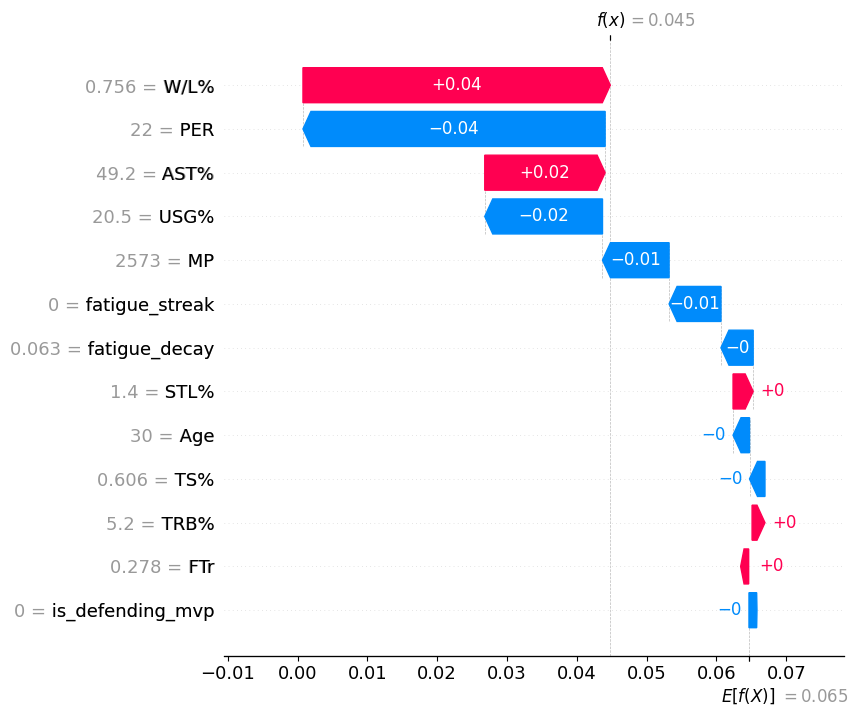


JUGADOR: Alonzo Mourning (1999) | Arquetipo A: Subestimación Algorítmica
Share Real: 0.655 | Predicción Algorítmica OOF: 0.032 | Residuo: +0.623


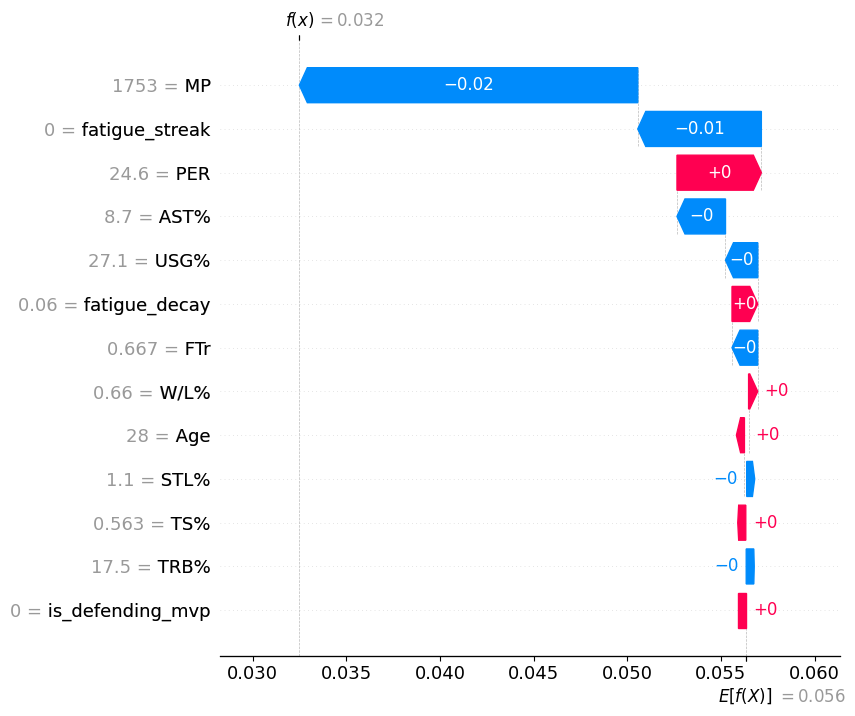


JUGADOR: Derrick Rose (2011) | Arquetipo A: Cortafuegos Narrativo
Share Real: 0.977 | Predicción Algorítmica OOF: 0.180 | Residuo: +0.797


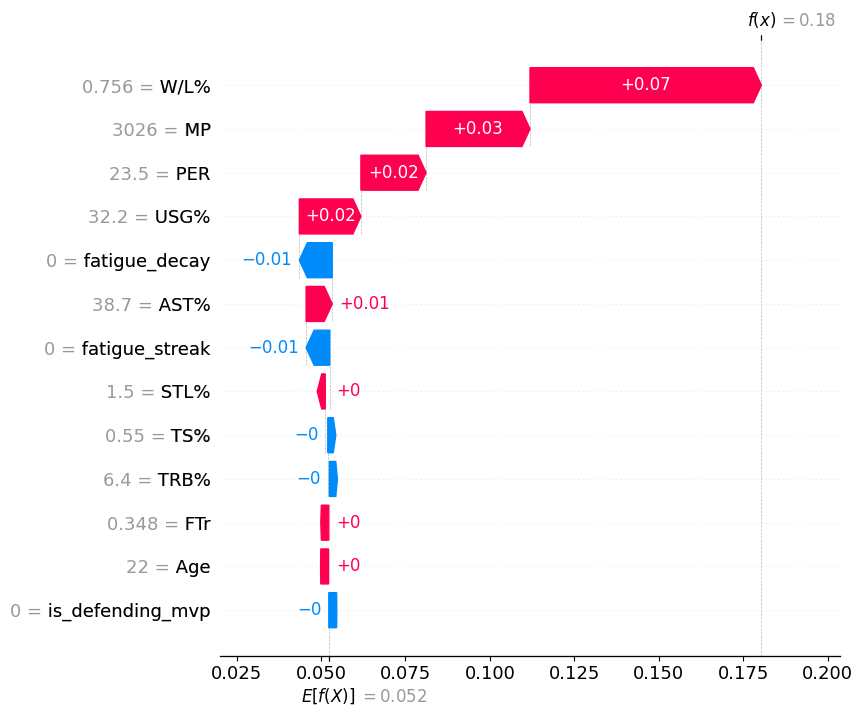


JUGADOR: Larry Bird (1987) | Arquetipo B: Fatiga por Tri-Campeonato
Share Real: 0.347 | Predicción Algorítmica OOF: 0.625 | Residuo: -0.278


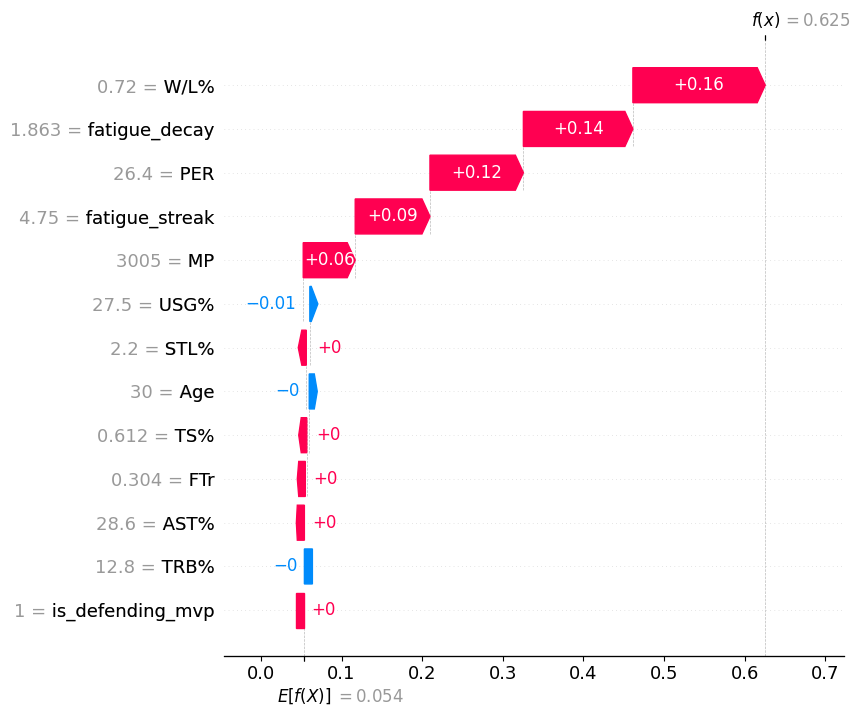

In [127]:


df_residuos_esc2 = df_meta_oof.copy()

df_residuos_esc2['y_pred'] = shap_explanation_esc2.base_values + shap_explanation_esc2.values.sum(axis=1)

df_residuos_esc2['Residuo_Neto'] = df_residuos_esc2['Share'] - df_residuos_esc2['y_pred']
df_residuos_esc2['Error_Absoluto'] = abs(df_residuos_esc2['Residuo_Neto'])

print("\n--- RANKING HISTÓRICO: MAYORES RESIDUOS NEGATIVOS (CASTIGOS DEL JURADO - VALIDACIÓN LOSO) ---")
top_castigos = df_residuos_esc2[(df_residuos_esc2['y_pred'] > 0.25) & (df_residuos_esc2['Residuo_Neto'] < -0.05)]\
    .nsmallest(7, 'Residuo_Neto')[[ "Player", "Season", "Share", "y_pred", "Residuo_Neto", "fatigue_decay"]]

display(top_castigos.round(4))

casos_auditoria = [
    {"Player": "Steve Nash", "Season": 2005, "Arquetipo": "Arquetipo A: Subestimación Algorítmica"},
    {"Player": "Alonzo Mourning", "Season": 1999, "Arquetipo": "Arquetipo A: Subestimación Algorítmica"},
    {"Player": "Derrick Rose", "Season": 2011, "Arquetipo": "Arquetipo A: Cortafuegos Narrativo"},
    {"Player": "Larry Bird", "Season": 1987, "Arquetipo": "Arquetipo B: Fatiga por Tri-Campeonato"}
]

print("\n--- GENERACIÓN DE DIAGRAMAS WATERFALL PARA AUDITORÍA LOCAL OUT-OF-FOLD ---")
for caso in casos_auditoria:
    mask = (df_residuos_esc2['Player'] == caso['Player']) & (df_residuos_esc2['Season'] == caso['Season'])

    if mask.any():
        pos_shap = df_residuos_esc2[mask].index[0]

        real_share = df_residuos_esc2.loc[pos_shap, 'Share']
        pred_share = df_residuos_esc2.loc[pos_shap, 'y_pred']
        res_neto   = df_residuos_esc2.loc[pos_shap, 'Residuo_Neto']

        print("\n" + "="*80)
        print(f"JUGADOR: {caso['Player']} ({caso['Season']}) | {caso['Arquetipo']}")
        print(f"Share Real: {real_share:.3f} | Predicción Algorítmica OOF: {pred_share:.3f} | Residuo: {res_neto:+.3f}")
        print("="*80)

        plt.figure(figsize=(10, 5))

        shap.plots.waterfall(shap_explanation_esc2[pos_shap], max_display=13)
        plt.show()
    else:
        print(f"⚠️ Alerta: No se encontró el registro fuera de la muestra para {caso['Player']} en la temporada {caso['Season']}.")


--- RANKING HISTÓRICO: MAYORES RESIDUOS NEGATIVOS (CASTIGOS DEL JURADO - VALIDACIÓN LOSO) ---


,Player,Season,Share,y_pred,Residuo_Neto,fatigue_decay
1546,Kevin Durant,2017,0.002,0.5818,-0.5798,0.9156
1565,Stephen Curry,2017,0.051,0.5714,-0.5204,1.5530
929,Amar'e Stoudemire,2005,0.032,0.5260,-0.4940,0.0000
1221,Dwyane Wade,2011,0.020,0.4753,-0.4553,0.4240
698,Shaquille O'Neal,1999,0.075,0.4993,-0.4243,0.5804
1010,Tim Duncan,2006,0.026,0.4038,-0.3778,0.9193
1618,Anthony Davis,2019,0.000,0.3745,-0.3745,0.4139



--- GENERACIÓN DE DIAGRAMAS WATERFALL PARA AUDITORÍA LOCAL OUT-OF-FOLD ---

JUGADOR: Steve Nash (2005) | Arquetipo A: Subestimación Algorítmica
Share Real: 0.839 | Predicción Algorítmica OOF: 0.045 | Residuo: +0.794


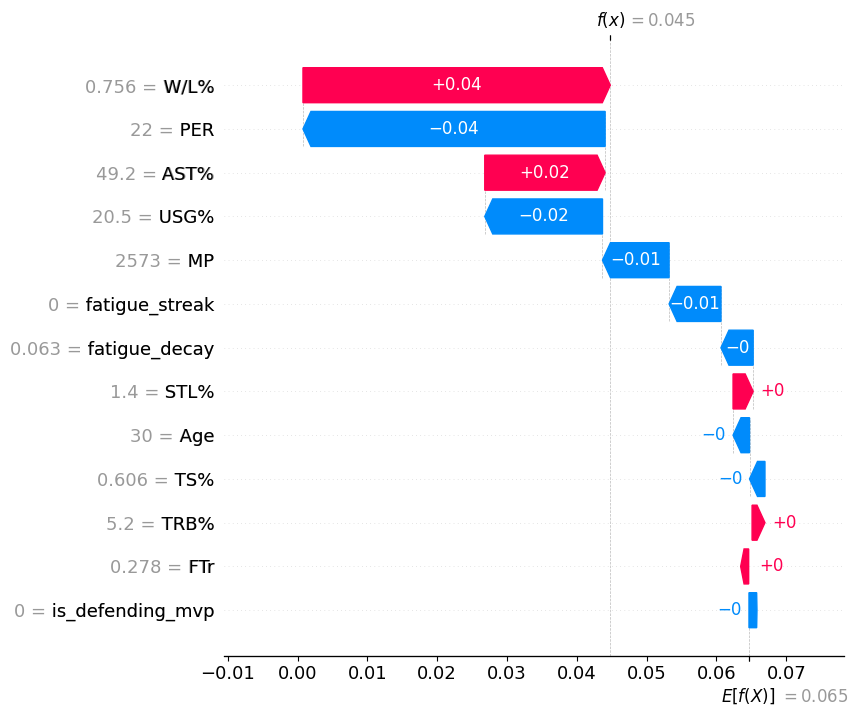


JUGADOR: Alonzo Mourning (1999) | Arquetipo A: Subestimación Algorítmica
Share Real: 0.655 | Predicción Algorítmica OOF: 0.032 | Residuo: +0.623


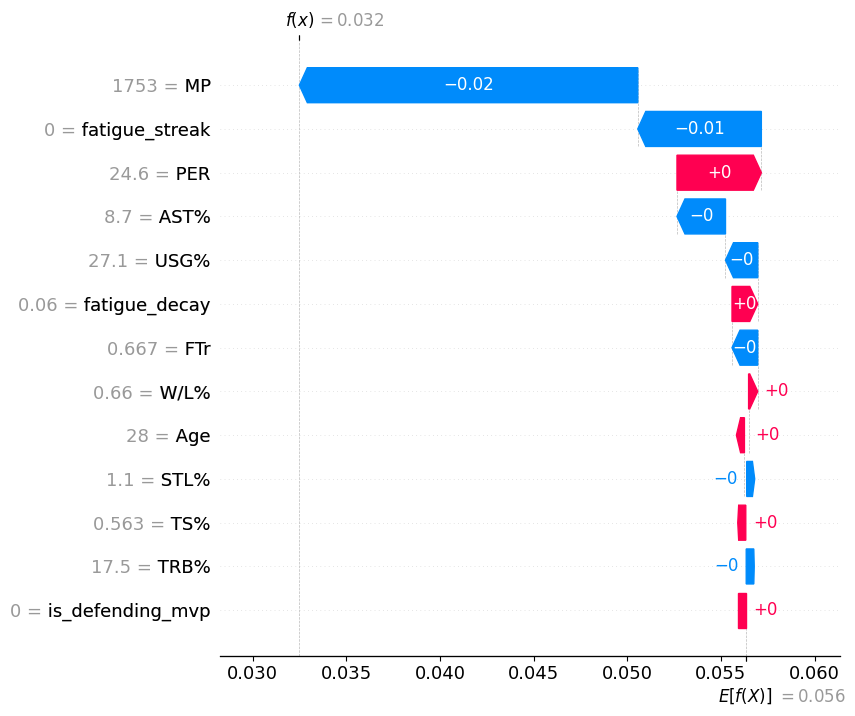


JUGADOR: Derrick Rose (2011) | Arquetipo A: Cortafuegos Narrativo
Share Real: 0.977 | Predicción Algorítmica OOF: 0.180 | Residuo: +0.797


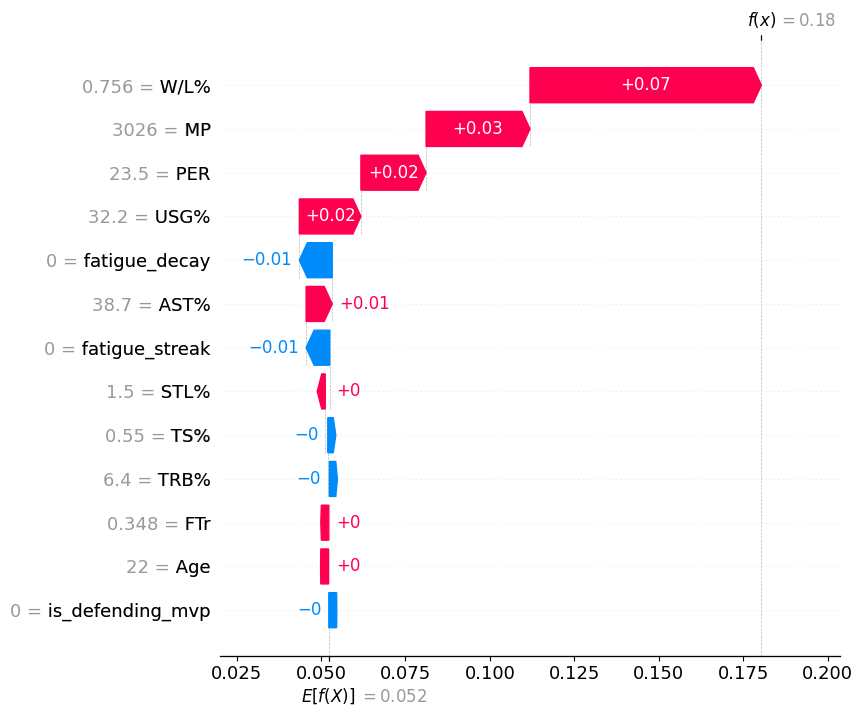


JUGADOR: Larry Bird (1987) | Arquetipo B: Fatiga por Tri-Campeonato
Share Real: 0.347 | Predicción Algorítmica OOF: 0.625 | Residuo: -0.278


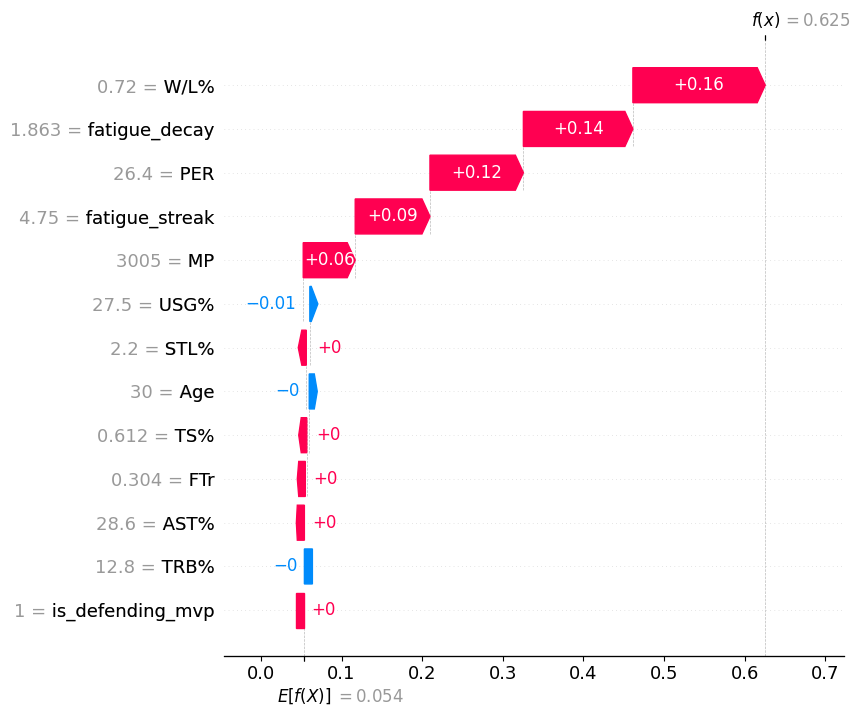


JUGADOR: Dwyane Wade (2011) | Estudio residuos
Share Real: 0.020 | Predicción Algorítmica OOF: 0.475 | Residuo: -0.455


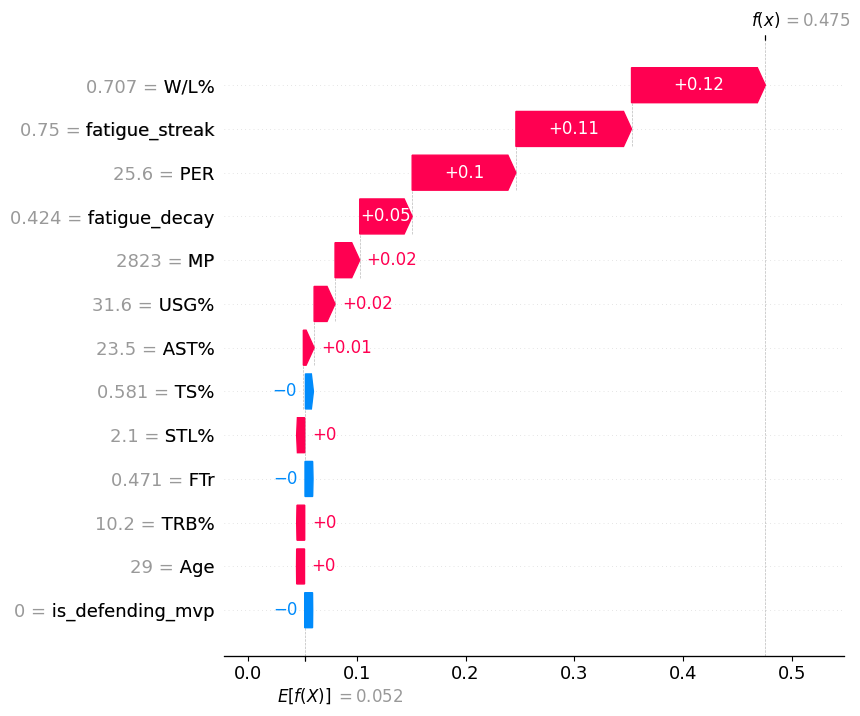


JUGADOR: Stephen Curry (2017) | Estudio residuos
Share Real: 0.051 | Predicción Algorítmica OOF: 0.571 | Residuo: -0.520


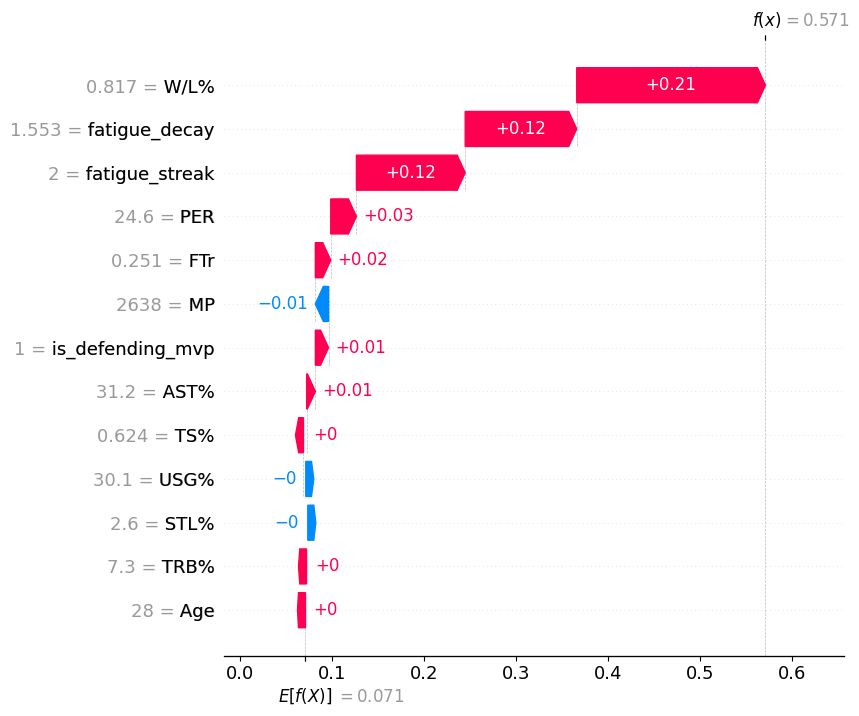


JUGADOR: Kevin Durant (2017) | Estudio residuos
Share Real: 0.002 | Predicción Algorítmica OOF: 0.582 | Residuo: -0.580


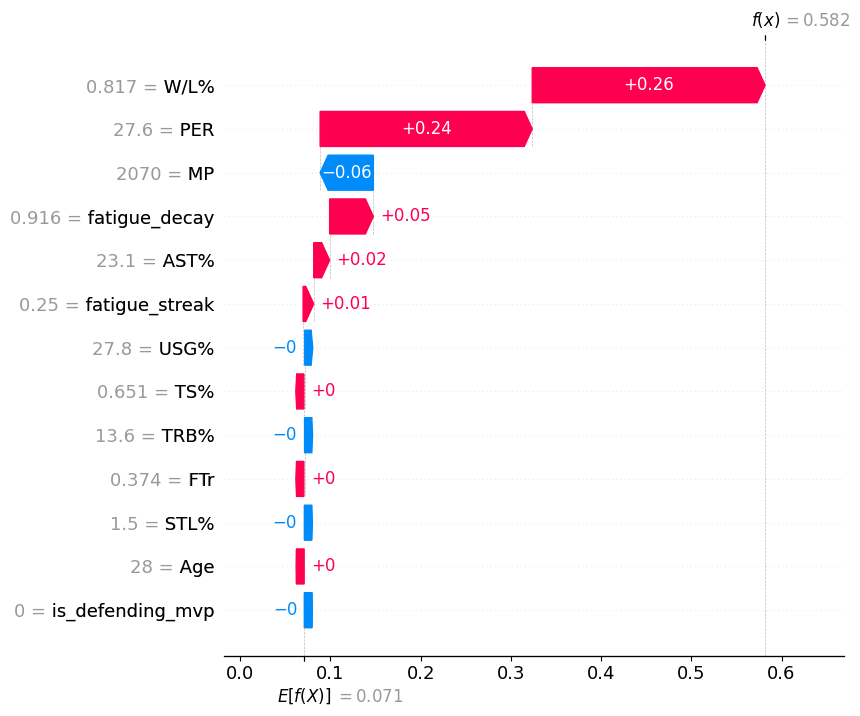


JUGADOR: Amar'e Stoudemire (2005) | Estudio residuos
Share Real: 0.032 | Predicción Algorítmica OOF: 0.526 | Residuo: -0.494


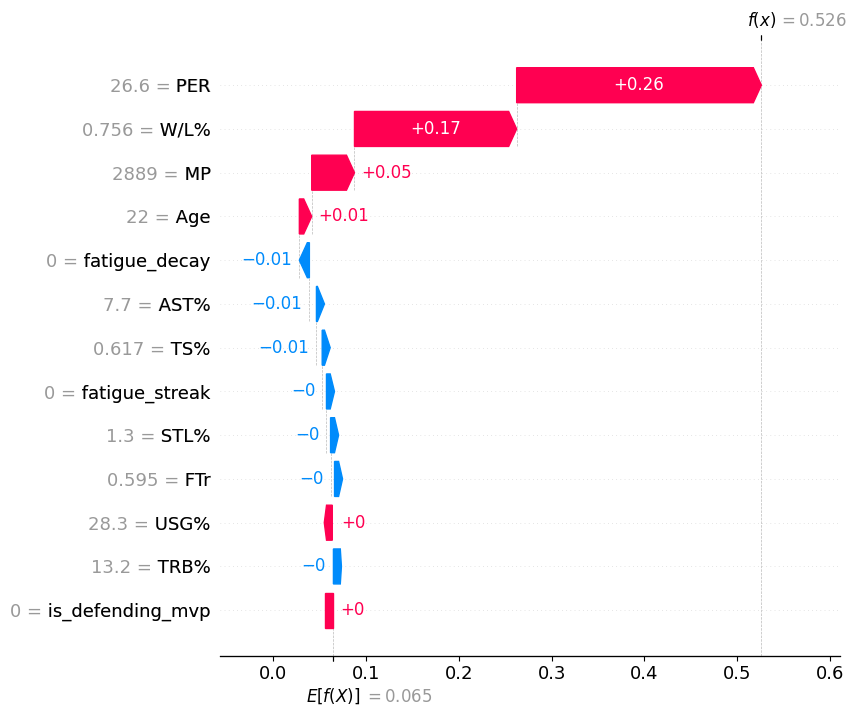


JUGADOR: Tim Duncan (2006) | Estudio residuos
Share Real: 0.026 | Predicción Algorítmica OOF: 0.404 | Residuo: -0.378


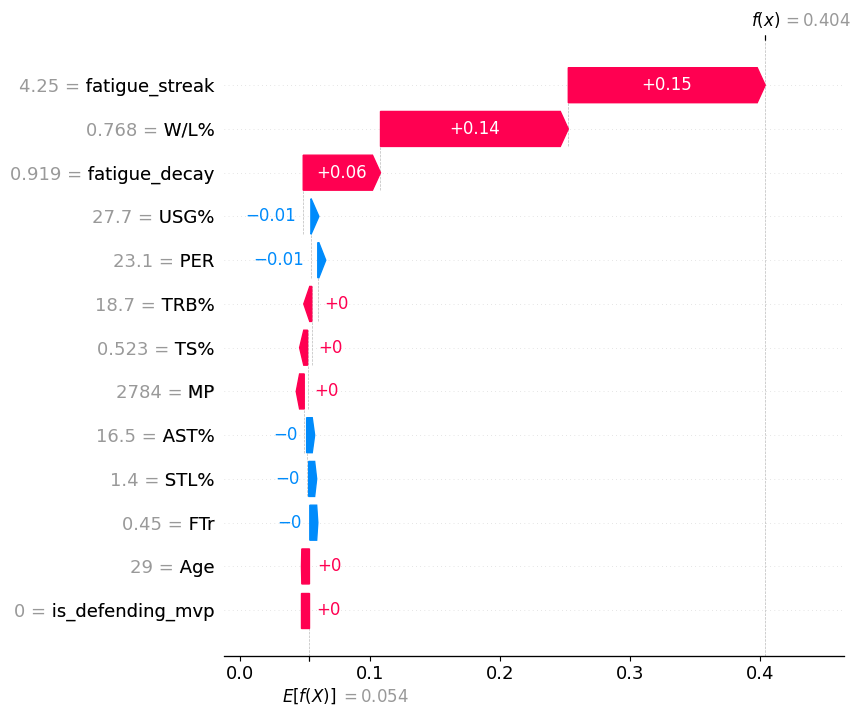


JUGADOR: Shaquille O'Neal (1999) | Estudio residuos
Share Real: 0.075 | Predicción Algorítmica OOF: 0.499 | Residuo: -0.424


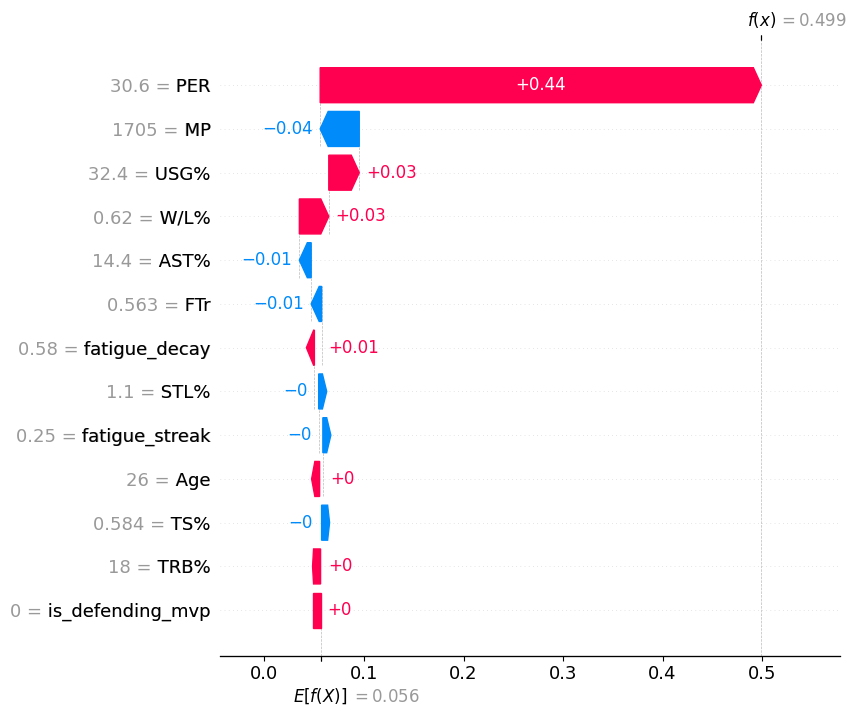


JUGADOR: Anthony Davis (2019) | Estudio residuos
Share Real: 0.000 | Predicción Algorítmica OOF: 0.375 | Residuo: -0.375


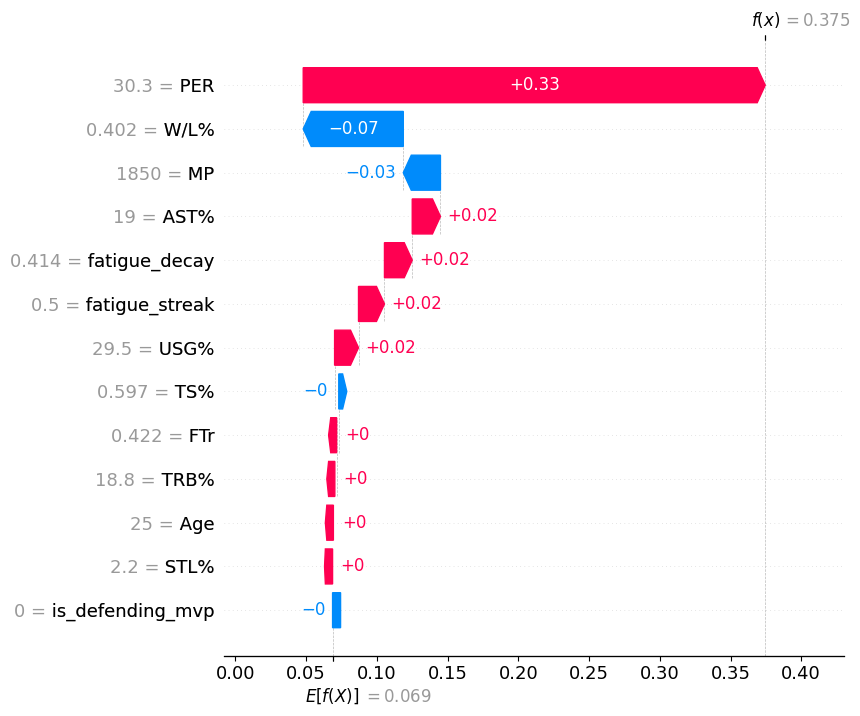


JUGADOR: LeBron James (2011) | Estudio casos polémicos
Share Real: 0.431 | Predicción Algorítmica OOF: 0.681 | Residuo: -0.250


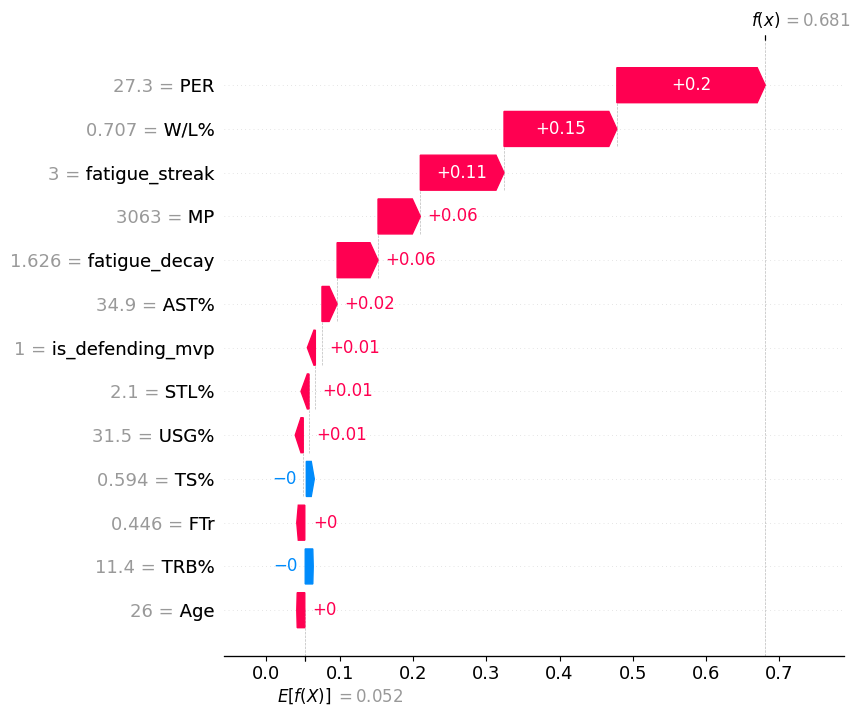


JUGADOR: Russell Westbrook (2017) | Estudio casos polémicos
Share Real: 0.879 | Predicción Algorítmica OOF: 0.485 | Residuo: +0.394


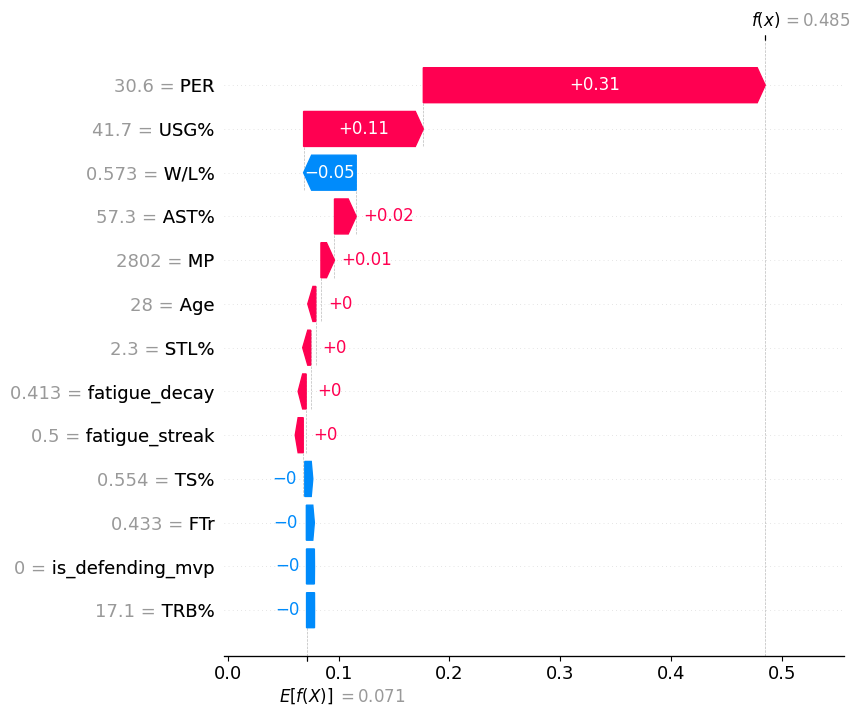


JUGADOR: Kawhi Leonard (2017) | Estudio casos polémicos
Share Real: 0.495 | Predicción Algorítmica OOF: 0.611 | Residuo: -0.116


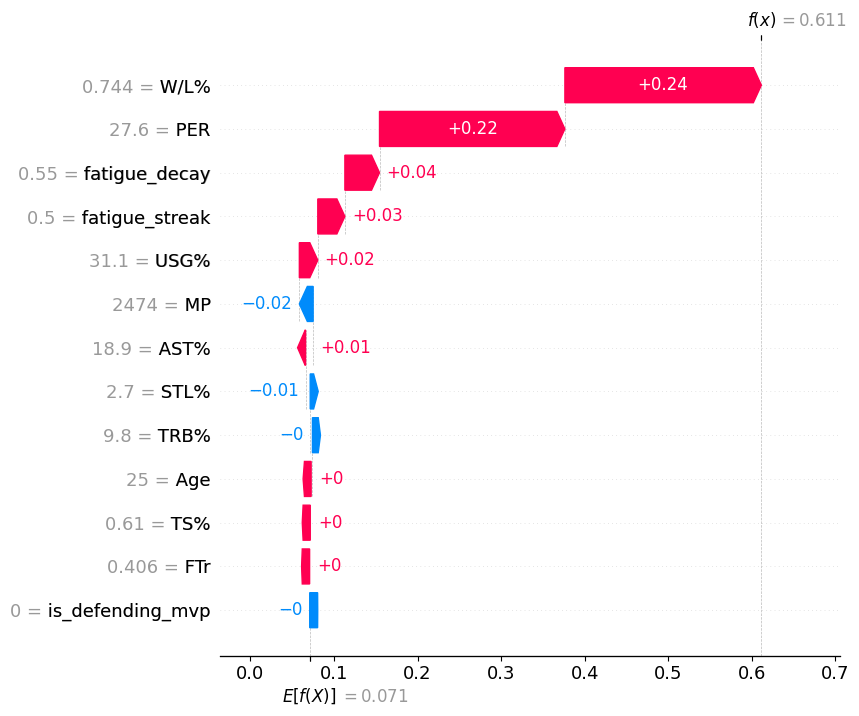


JUGADOR: Larry Bird (1987) | Estudio casos polémicos
Share Real: 0.347 | Predicción Algorítmica OOF: 0.625 | Residuo: -0.278


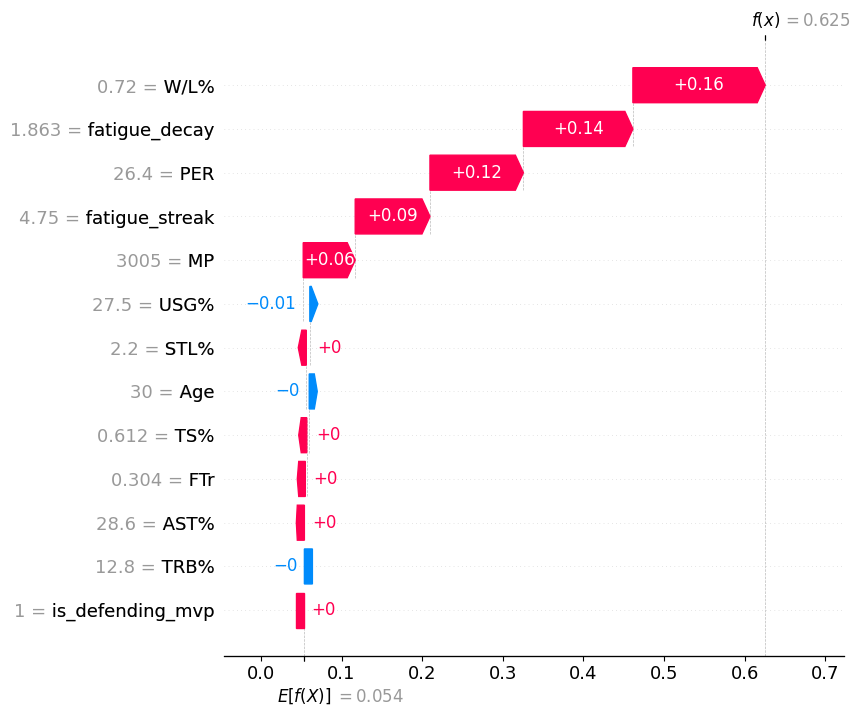


JUGADOR: Magic Johnson (1987) | Estudio casos polémicos
Share Real: 0.940 | Predicción Algorítmica OOF: 0.702 | Residuo: +0.238


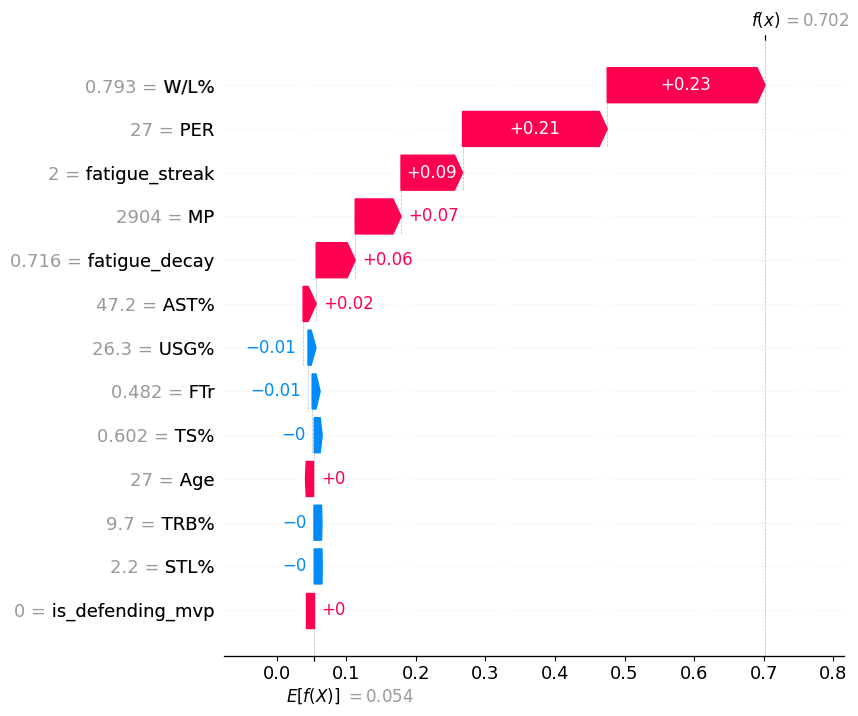


JUGADOR: Michael Jordan (1993) | Estudio casos polémicos
Share Real: 0.577 | Predicción Algorítmica OOF: 0.791 | Residuo: -0.214


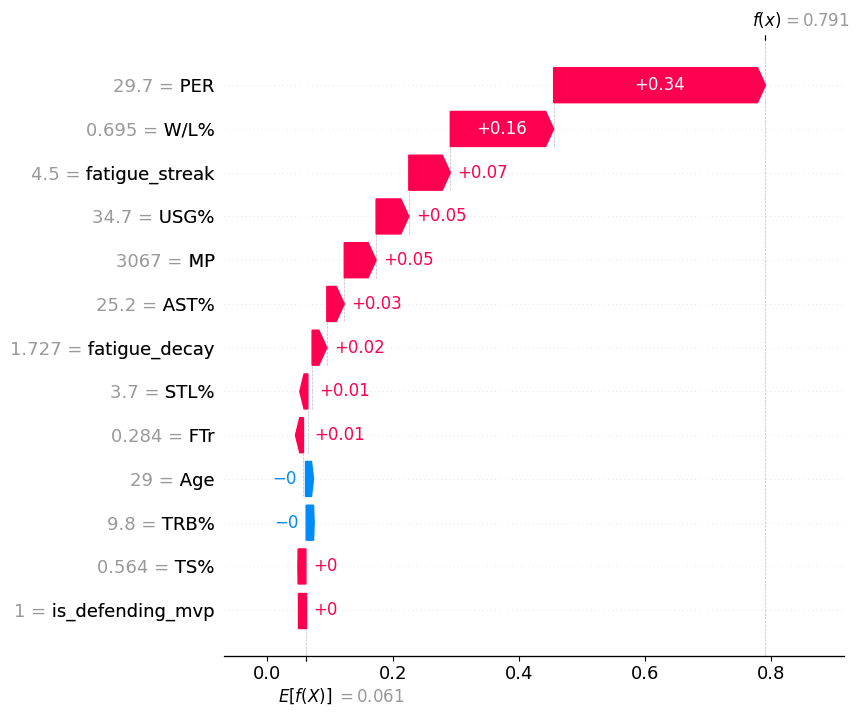


JUGADOR: Charles Barkley (1993) | Estudio casos polémicos
Share Real: 0.852 | Predicción Algorítmica OOF: 0.354 | Residuo: +0.498


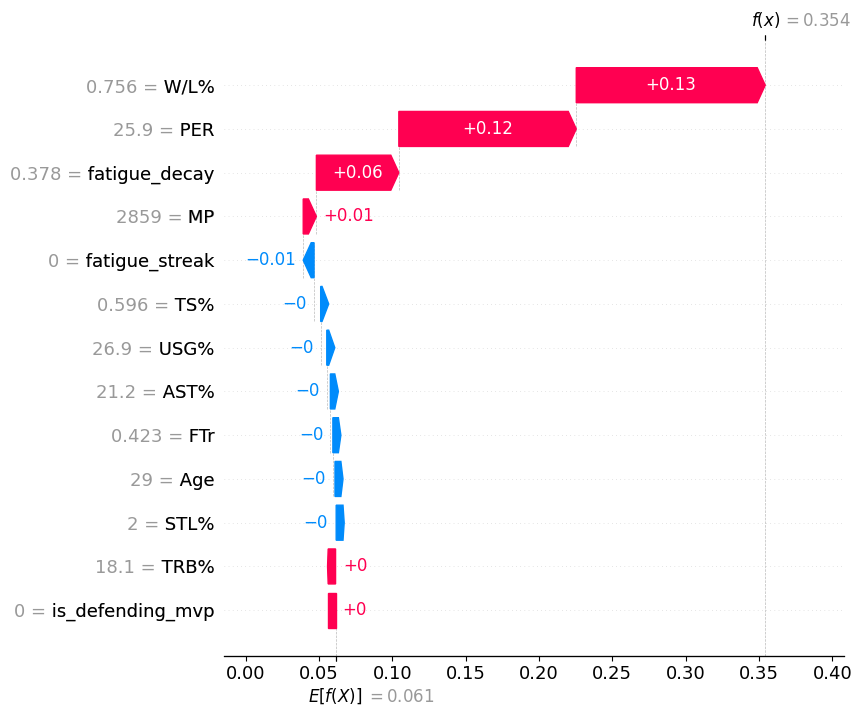

In [128]:


df_residuos_esc2 = df_meta_oof.copy()

df_residuos_esc2['y_pred'] = shap_explanation_esc2.base_values + shap_explanation_esc2.values.sum(axis=1)

df_residuos_esc2['Residuo_Neto'] = df_residuos_esc2['Share'] - df_residuos_esc2['y_pred']
df_residuos_esc2['Error_Absoluto'] = abs(df_residuos_esc2['Residuo_Neto'])

print("\n--- RANKING HISTÓRICO: MAYORES RESIDUOS NEGATIVOS (CASTIGOS DEL JURADO - VALIDACIÓN LOSO) ---")
top_castigos = df_residuos_esc2[(df_residuos_esc2['y_pred'] > 0.25) & (df_residuos_esc2['Residuo_Neto'] < -0.05)]\
    .nsmallest(7, 'Residuo_Neto')[[ "Player", "Season", "Share", "y_pred", "Residuo_Neto", "fatigue_decay"]]
display(top_castigos.round(4))

casos_auditoria = [
    {"Player": "Steve Nash", "Season": 2005, "Arquetipo": "Arquetipo A: Subestimación Algorítmica"},
    {"Player": "Alonzo Mourning", "Season": 1999, "Arquetipo": "Arquetipo A: Subestimación Algorítmica"},
    {"Player": "Derrick Rose", "Season": 2011, "Arquetipo": "Arquetipo A: Cortafuegos Narrativo"},
    {"Player": "Larry Bird", "Season": 1987, "Arquetipo": "Arquetipo B: Fatiga por Tri-Campeonato"},
    {"Player": "Dwyane Wade", "Season": 2011, "Arquetipo": "Estudio residuos"},
    {"Player": "Stephen Curry", "Season": 2017, "Arquetipo": "Estudio residuos"},
    {"Player": "Kevin Durant", "Season": 2017, "Arquetipo": "Estudio residuos"},
    {"Player": "Amar'e Stoudemire", "Season": 2005, "Arquetipo": "Estudio residuos"},
    {"Player": "Tim Duncan", "Season": 2006, "Arquetipo": "Estudio residuos"},
    {"Player": "Shaquille O'Neal", "Season": 1999, "Arquetipo": "Estudio residuos"},
    {"Player": "Anthony Davis", "Season": 2019, "Arquetipo": "Estudio residuos"},
    {"Player": "LeBron James", "Season": 2011, "Arquetipo": "Estudio casos polémicos"},
    {"Player": "Russell Westbrook", "Season": 2017, "Arquetipo": "Estudio casos polémicos"},
    {"Player": "Kawhi Leonard", "Season": 2017, "Arquetipo": "Estudio casos polémicos"},
    {"Player": "Larry Bird", "Season": 1987, "Arquetipo": "Estudio casos polémicos"},
    {"Player": "Magic Johnson", "Season": 1987, "Arquetipo": "Estudio casos polémicos"},
    {"Player": "Michael Jordan", "Season": 1993, "Arquetipo": "Estudio casos polémicos"},
    {"Player": "Charles Barkley", "Season": 1993, "Arquetipo": "Estudio casos polémicos"}
]

print("\n--- GENERACIÓN DE DIAGRAMAS WATERFALL PARA AUDITORÍA LOCAL OUT-OF-FOLD ---")
for caso in casos_auditoria:
    mask = (df_residuos_esc2['Player'] == caso['Player']) & (df_residuos_esc2['Season'] == caso['Season'])

    if mask.any():
        pos_shap = df_residuos_esc2[mask].index[0]

        real_share = df_residuos_esc2.loc[pos_shap, 'Share']
        pred_share = df_residuos_esc2.loc[pos_shap, 'y_pred']
        res_neto   = df_residuos_esc2.loc[pos_shap, 'Residuo_Neto']

        print("\n" + "="*80)
        print(f"JUGADOR: {caso['Player']} ({caso['Season']}) | {caso['Arquetipo']}")
        print(f"Share Real: {real_share:.3f} | Predicción Algorítmica OOF: {pred_share:.3f} | Residuo: {res_neto:+.3f}")
        print("="*80)

        plt.figure(figsize=(10, 5))

        shap.plots.waterfall(shap_explanation_esc2[pos_shap], max_display=13)
        plt.show()
    else:
        print(f"⚠️ Alerta: No se encontró el registro fuera de la muestra para {caso['Player']} en la temporada {caso['Season']}.")

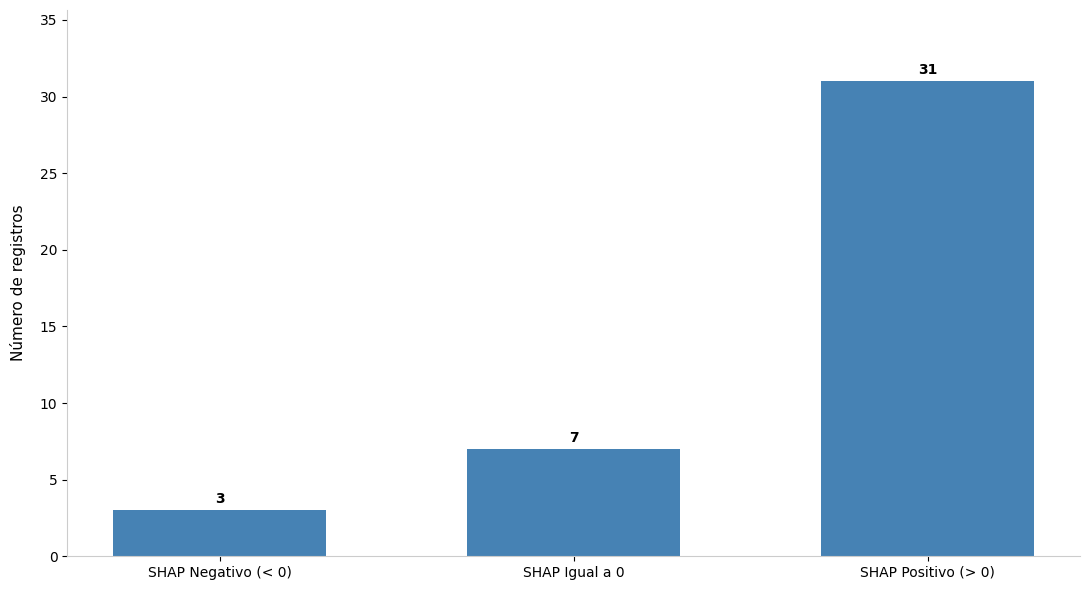

In [129]:

idx_def = FEATURES.index('is_defending_mvp')

shap_def = shap_explanation_esc2.values[:, idx_def]

mask = df_meta_oof['is_defending_mvp'] == 1
shap_defensores = shap_def[mask]

negativos = (shap_defensores < 0).sum()
positivos = (shap_defensores > 0).sum()
neutrales = (shap_defensores == 0).sum()

categorias = ['SHAP Negativo (< 0)', 'SHAP Igual a 0', 'SHAP Positivo (> 0)']
valores = [negativos, neutrales, positivos]


fig, ax = plt.subplots(figsize=(11, 6))

barras = ax.bar(categorias, valores, color='steelblue', width=0.6, edgecolor='none')

ax.set_ylabel('Número de registros', fontsize=11, labelpad=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

for barra in barras:
    height = barra.get_height()
    ax.annotate(f'{height}',
                xy=(barra.get_x() + barra.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylim(0, max(valores) * 1.15)

plt.tight_layout()
plt.show()

In [130]:

idx_def = FEATURES.index('is_defending_mvp')

shap_def = shap_explanation_esc2.values[:, idx_def]

mask = df_meta_oof['is_defending_mvp'] == 1
shap_defensores = shap_def[mask]

print("=== SHAP de is_defending_mvp (solo defensores - Escenario 2) ===")
print(f"Total defensores en dataset:  {mask.sum()}")
print(f"Con SHAP negativo:            {(shap_defensores < 0).sum()}")
print(f"Con SHAP positivo:            {(shap_defensores > 0).sum()}")
print(f"Con SHAP = 0:                 {(shap_defensores == 0).sum()}")
print(f"SHAP medio:                   {shap_defensores.mean():.4f}")
print(f"SHAP mediano:                 {np.median(shap_defensores):.4f}")

df_defensores = df_meta_oof[mask][['Player', 'Season', 'Share']].copy()

df_defensores['shap_is_defending'] = shap_defensores

print("\n=== Detalle por jugador ===")
print(df_defensores.sort_values('shap_is_defending', ascending=False).to_string())

=== SHAP de is_defending_mvp (solo defensores - Escenario 2) ===
Total defensores en dataset:  41
Con SHAP negativo:            3
Con SHAP positivo:            31
Con SHAP = 0:                 7
SHAP medio:                   0.0060
SHAP mediano:                 0.0040

=== Detalle por jugador ===
                     Player  Season  Share  shap_is_defending
166            Moses Malone    1984  0.046           0.025822
1060             Steve Nash    2007  0.785           0.024847
641             Karl Malone    1998  0.726           0.016701
367           Magic Johnson    1990  0.691           0.016388
1565          Stephen Curry    2017  0.051           0.014306
1881           Nikola Jokić    2023  0.674           0.014134
486         Charles Barkley    1994  0.005           0.012014
1192           LeBron James    2010  0.980           0.011629
1989           Nikola Jokić    2025  0.787           0.010846
55      Kareem Abdul-Jabbar    1981  0.414           0.010702
1339           LeBro

In [131]:

df_loso_esc1 = df_meta_oof.copy()

df_loso_esc1['y_pred_esc1'] = shap_explanation_esc1.base_values + shap_explanation_esc1.values.sum(axis=1)

idx_max_esc1 = df_loso_esc1.groupby('Season')['y_pred_esc1'].idxmax()
max_pred_esc1_per_season = df_loso_esc1.loc[idx_max_esc1].sort_values(by='Season')

print("\n--- ESCENARIO 1: Jugador con Mayor Share Predicho por Temporada (Rendimiento Puro) ---")
display(max_pred_esc1_per_season[['Season', 'Player', 'y_pred_esc1', 'Share']].round(4))

df_loso_esc2 = df_meta_oof.copy()

df_loso_esc2['y_pred_esc2'] = shap_explanation_esc2.base_values + shap_explanation_esc2.values.sum(axis=1)

idx_max_esc2 = df_loso_esc2.groupby('Season')['y_pred_esc2'].idxmax()
max_pred_esc2_per_season = df_loso_esc2.loc[idx_max_esc2].sort_values(by='Season')

print("\n--- ESCENARIO 2: Jugador con Mayor Share Predicho por Temporada (Con Fatiga) ---")
display(max_pred_esc2_per_season[['Season', 'Player', 'y_pred_esc2', 'Share']].round(4))


--- ESCENARIO 1: Jugador con Mayor Share Predicho por Temporada (Rendimiento Puro) ---


,Season,Player,y_pred_esc1,Share
14,1980,Kareem Abdul-Jabbar,0.5103,0.665
54,1981,Julius Erving,0.5362,0.658
91,1982,Moses Malone,0.2405,0.735
130,1983,Moses Malone,0.4279,0.960
160,1984,Larry Bird,0.4087,0.858
198,1985,Larry Bird,0.7974,0.978
228,1986,Larry Bird,0.5356,0.981
267,1987,Magic Johnson,0.7726,0.940
304,1988,Michael Jordan,0.7005,0.831
334,1989,Michael Jordan,0.6529,0.704



--- ESCENARIO 2: Jugador con Mayor Share Predicho por Temporada (Con Fatiga) ---


,Season,Player,y_pred_esc2,Share
14,1980,Kareem Abdul-Jabbar,0.3100,0.665
54,1981,Julius Erving,0.5155,0.658
84,1982,Julius Erving,0.4004,0.294
130,1983,Moses Malone,0.6018,0.960
160,1984,Larry Bird,0.4511,0.858
198,1985,Larry Bird,0.8277,0.978
228,1986,Larry Bird,0.5989,0.981
267,1987,Magic Johnson,0.7020,0.940
304,1988,Michael Jordan,0.7187,0.831
334,1989,Michael Jordan,0.6637,0.704
